# **Práctico Entregable Aprendizaje No Supervisado 2026**


Utilizar la base de jugadores “male_players.csv” disponible en la página de Kaggle https://www.kaggle.com/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset?select=male_players.csv.

## **1. Análisis exploratorio inicial de la base.**
### 1.1. Dimensiones de la base  y tipos de variables presentes (numéricas, categóricas, identificadores, etc.).

In [129]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 150)
pd.set_option('display.max_rows', 200)
import itertools
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [130]:
!pip install -q kagglehub
import kagglehub

path = kagglehub.dataset_download("stefanoleone992/ea-sports-fc-24-complete-player-dataset")
print(path)
!ls "{path}"

Using Colab cache for faster access to the 'ea-sports-fc-24-complete-player-dataset' dataset.
/kaggle/input/ea-sports-fc-24-complete-player-dataset
female_coaches.csv  female_teams.csv  male_players.csv
female_players.csv  male_coaches.csv  male_teams.csv


In [131]:
df = pd.read_csv(f"{path}/male_players.csv", low_memory=False)
df.head()

,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_id,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined_date,club_contract_valid_until_year,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,181500000.0,230000.0,24,1998-12-20,182,75,73.0,Paris Saint Germain,16.0,Ligue 1,1.0,LW,7.0,NaN,2018-07-01,2024.0,18,France,1335.0,LW,10.0,Right,4,5,5,High/Low,Unique,Yes,349400000.0,"#Speedster, #Dribbler, #Acrobat, #Clinical fin...","Quick Step +, Rapid, Flair, Trivela",97.0,90.0,80.0,92.0,36.0,78.0,78,94,73,86,84,93,80,69,71,92,97,97,93,93,82,90,88,88,77,83,64,38,93,83,84,88.0,26,34,32,13,5,7,11,6,NaN,90+3,90+3,90+3,91,91,91,91,91,89+3,89+3,89+3,89+3,81+3,81+3,81+3,89+3,68+3,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,185000000.0,340000.0,22,2000-07-21,195,94,10.0,Manchester City,13.0,Premier League,1.0,ST,9.0,NaN,2022-07-01,2027.0,36,Norway,1352.0,ST,9.0,Left,3,3,5,High/Medium,Unique,Yes,356100000.0,"#Aerial threat, #Distance shooter, #Strength, ...","Acrobatic +, Power Header, Quick Step",89.0,93.0,66.0,80.0,45.0,88.0,47,96,83,77,90,79,77,62,53,82,82,94,76,94,72,94,93,76,93,86,87,43,96,74,84,87.0,38,47,29,7,14,13,11,7,NaN,90+3,90+3,90+3,82,86,86,86,82,82+3,82+3,82+3,79+3,74+3,74+3,74+3,79+3,62+3,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,103000000.0,350000.0,32,1991-06-28,181,75,10.0,Manchester City,13.0,Premier League,1.0,SUB,17.0,NaN,2015-08-30,2025.0,7,Belgium,1325.0,CAM,7.0,Right,5,4,5,High/Medium,Unique,Yes,190600000.0,"#Dribbler, #Playmaker, #Distance shooter, #Cro...","Pinged Pass +, Dead Ball, Incisive Pass, Long ...",72.0,88.0,94.0,87.0,65.0,78.0,95,85,55,94,83,86,92,83,94,92,72,72,74,92,78,92,72,88,74,92,75,66,88,95,83,88.0,66,70,53,15,13,5,10,13,NaN,83+3,83+3,83+3,87,88,88,88,87,89+2,89+2,89+2,88+3,90+1,90+1,90+1,88+3,79+3,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,41000000.0,23000.0,36,1987-06-24,169,67,112893.0,Inter Miami,39.0,Major League Soccer,1.0,RF,10.0,NaN,2023-07-16,2025.0,52,Argentina,1369.0,RW,10.0,Left,4,4,5,Low/Low,Unique,Yes,61500000.0,"#Dribbler, #Playmaker, #FK Specialist, #Acroba...","Technical +, Finesse Shot, Dead Ball, Pinged P...",80.0,87.0,90.0,94.0,33.0,64.0,83,89,60,91,86,96,93,93,90,93,87,74,91,88,95,83,71,70,68,90,44,40,91,92,75,96.0,20,35,24,6,11,15,14,8,NaN,85+3,85+3,85+3,90,89,89,89,90,91-1,91-1,91-1,89+1,85+3,85+3,85+3,89+1,64+3,63+3,63+3,63+3,64+3,59+3,49+3,49+3,49+3,59+3,

In [132]:
# Cantidad de filas y columnas
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

Cantidad de filas: 180021
Cantidad de columnas: 109


El dataset combina múltiples versiones de FIFA/FC por jugador. El csv trae 10 años de versiones del juego apiladas, y cada jugador aparece una vez por cada versión en la que fue incluido.  

In [133]:
print("Cantidad de jugadores únicos (player_id):", df['player_id'].nunique())
versiones = sorted(int(v) for v in df['fifa_version'].unique())
print(versiones)

Cantidad de jugadores únicos (player_id): 53111
[15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [134]:
# ¿Cuántas veces aparece cada jugador en todas las versiones?
apariciones_por_jugador = df.groupby('player_id').size()
apariciones_por_jugador.describe()

,0
count,53111.000000
mean,3.389524
std,2.644226
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,10.000000


In [135]:
 #¿Un mismo jugador puede tener más de una fila o de un fifa_update por versión?
duplicados_dentro_version = df.groupby(['player_id','fifa_version']).size()
print("Máximo de filas para un mismo jugador en la misma versión:", duplicados_dentro_version.max())
print("Cantidad de casos con más de 1 fila en la misma versión:", (duplicados_dentro_version>1).sum())

Máximo de filas para un mismo jugador en la misma versión: 1
Cantidad de casos con más de 1 fila en la misma versión: 0


In [136]:
# Tipos de datos por columna
df.dtypes.value_counts()

,count
object,46
int64,43
float64,20


In [137]:
# Columna por columna: tipo, nº de valores únicos y % de nulos
resumen = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'pct_nulos': df.isnull().mean()*100
}).sort_values('pct_nulos', ascending=False)
resumen

,dtype,n_unique,pct_nulos
nation_team_id,float64,56,94.390654
nation_position,object,29,94.390654
nation_jersey_number,float64,34,94.390654
club_loaned_from,object,831,94.043473
player_tags,object,204,92.268680
goalkeeping_speed,float64,57,88.876853
player_traits,object,5208,54.558079
release_clause_eur,float64,1919,32.940046
mentality_composure,float64,88,18.268980
shooting,float64,81,11.123147


La base tiene 180.021 filas y 109 columnas. Es importante notar que el dataset combina 10 versiones de videojuego (FIFA 15 a FC 24) identificadas por la columna fifa_version: hay 53.111 jugadores únicos (player_id), cada uno apareciendo en promedio 3.4 versiones distintas (mediana 2, máximo 10) un jugador por versión sin duplicados dentro de la misma versión. *Este punto se retoma en la sección 1.3.*


En cuanto a tipos de variables, la base combina identificadores (player_id, player_url), variables numéricas continuas y discretas de habilidad/desempeño, variables categóricas (posición, equipo, nacionalidad, pie hábil, etc) variables de texto libre (player_traits, player_tags), fechas, (dob, club_joined_date), y columnas de rating por posición (st, cb, gk, etc) que están en formato object porque incluyen modificadores en lugar de número limpio.

### **1.2. Identificación de las columnas relevantes**

 Encontrar grupos de jugadores con habilidades equivalentes), descartando desde el inicio aquellas que claramente no aportan (identificadores, URLs de imágenes, etc.). Justificación explícita de qué variables se conservan y cuáles se descartan para las etapas siguientes del trabajo, explicando el criterio utilizado (relevancia para el objetivo, redundancia con otras variables, calidad de los datos, etc.).

El objetivo del trabajo es agrupar jugadores se´gun habilidades equivalente, por lo que priorizamos las variables de desempeño técnico/físico. Se descartan identificadosres, URLs, metadatos administrativos y variables de texto libre que no aportan comparación de habilidades entre jugadores.

In [138]:
#Exploración de columnas por familia
cols = df.columns.tolist()
familias = ['attacking_', 'skill_', 'movement_', 'power_', 'mentality_',
            'defending_', 'goalkeeping_', 'club_', 'nation_', 'league_']

for fam in familias:
    matched = [c for c in cols if c.startswith(fam)]
    print(f"{fam:15s} ({len(matched)}): {matched}")

print("\nSin prefijo reconocido:")
resto = [c for c in cols if not any(c.startswith(f) for f in familias)]
print(resto)

attacking_      (5): ['attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys']
skill_          (6): ['skill_moves', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control']
movement_       (5): ['movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance']
power_          (5): ['power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots']
mentality_      (6): ['mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure']
defending_      (3): ['defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle']
goalkeeping_    (6): ['goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes', 'goalkeeping_speed']
club_           (7): ['club_team_i

In [139]:
# Clasificación de columnas en categorías
def clasificar_columna(col):
    if col in ['player_id','player_url']:
        return 'Identificador'
    if col in ['fifa_version','fifa_update','update_as_of']:
        return 'Metadata de versión'
    if col in ['short_name','long_name']:
        return 'Nombre (identificador textual)'
    if col == 'dob':
        return 'Redundante (usar age)'
    if col in ['club_team_id','club_jersey_number','club_loaned_from','club_joined_date','club_contract_valid_until_year']:
        return 'Metadata de club (no habilidad)'
    if col in ['nation_team_id','nation_position','nation_jersey_number']:
        return 'Metadata de selección (no habilidad)'
    if col == 'league_id':
        return 'Identificador de liga'
    if col in ['player_tags','player_traits','body_type','real_face']:
        return 'Texto libre / baja utilidad'
    if col in ['value_eur','wage_eur','release_clause_eur']:
        return 'Económica (no habilidad)'
    posiciones_cortas = ['ls','st','rs','lw','lf','cf','rf','rw','lam','cam','ram','lm',
                         'lcm','cm','rcm','rm','lwb','ldm','cdm','rdm','rwb','lb','lcb','cb','rcb','rb','gk']
    if col in posiciones_cortas:
        return 'Rating por posición (derivado)'
    if col.startswith(('attacking_','skill_','movement_','power_','mentality_','defending_','goalkeeping_')):
        return 'Habilidad (numérica) - CONSERVAR'
    if col in ['overall','potential','pace','shooting','passing','dribbling','defending','physic',
               'age','height_cm','weight_kg']:
        return 'Habilidad/física global (numérica) - CONSERVAR'
    if col in ['player_positions','club_position','club_name','league_name','league_level',
               'nationality_id','nationality_name','preferred_foot','work_rate','weak_foot',
               'skill_moves','international_reputation']:
        return 'Categórica relevante - CONSERVAR'
    return 'Revisar'

resumen_cols = pd.DataFrame({
    'columna': df.columns,
    'dtype': df.dtypes.values,
    'categoria': [clasificar_columna(c) for c in df.columns]
}).sort_values(['categoria','columna']).reset_index(drop=True)

resumen_cols

,columna,dtype,categoria
0,club_name,object,Categórica relevante - CONSERVAR
1,club_position,object,Categórica relevante - CONSERVAR
2,international_reputation,int64,Categórica relevante - CONSERVAR
3,league_level,float64,Categórica relevante - CONSERVAR
4,league_name,object,Categórica relevante - CONSERVAR
5,nationality_id,int64,Categórica relevante - CONSERVAR
6,nationality_name,object,Categórica relevante - CONSERVAR
7,player_positions,object,Categórica relevante - CONSERVAR
8,preferred_foot,object,Categórica relevante - CONSERVAR
9,weak_foot,int64,Categórica relevante - CONSERVAR


In [140]:
# Verificación formato  de las columnas de rating por posición
print(df[['st','cb','gk']].head())

     st    cb    gk
0  90+3  54+3  18+3
1  90+3  62+3  19+3
2  83+3  70+3  21+3
3  85+3  49+3  19+3
4  88+2  55+3  18+3


In [141]:
# Se agrega una columna de Acción (Conservar/Descartar) para agrupar mejor
resumen_cols['accion'] = resumen_cols['categoria'].apply(
    lambda c: 'Conservar' if 'CONSERVAR' in c else 'Descartar'
)

tabla_resumen = (
    resumen_cols
    .groupby(['accion','categoria'])
    .size()
    .reset_index(name='n_columnas')
    .sort_values(['accion','n_columnas'], ascending=[True, False])
    .reset_index(drop=True)
)
tabla_resumen

,accion,categoria,n_columnas
0,Conservar,Habilidad (numérica) - CONSERVAR,36
1,Conservar,Categórica relevante - CONSERVAR,11
2,Conservar,Habilidad/física global (numérica) - CONSERVAR,11
3,Descartar,Rating por posición (derivado),27
4,Descartar,Metadata de club (no habilidad),5
5,Descartar,Texto libre / baja utilidad,4
6,Descartar,Económica (no habilidad),3
7,Descartar,Metadata de selección (no habilidad),3
8,Descartar,Metadata de versión,3
9,Descartar,Identificador,2


In [142]:
print(resumen_cols['accion'].value_counts())
print("\nTotal columnas:", resumen_cols.shape[0], "(debe dar 109)")

accion
Conservar    58
Descartar    51
Name: count, dtype: int64

Total columnas: 109 (debe dar 109)


Se descartan identificadores (player_id, player_url), nombres (short_name, long_name), metadata de club/selección/equipo que no tienen relación directa con el desempeño (número de camiseta, fechas de contrato, IDs), variables de texto libre (player_tags, player traits, body_type, real_face), dob es redundante con age, y los ratings posicionales (ls, gk) que son combinaciones derivadas de las habilidades base junto con la posición, viene  en formato object en lugar de numérico.

Las variables económicas (value_eur, wage_eur, release_clause_eur) se excluyen del vector de clustering porque reflejan mercado y no habilidad, aunque se conservan a parte para caracterizar clusters resultantes.

Se conservan 58 columnas: 47 numéricas de habilidad y desempeño, y 11 categóricas que se usan para describir y visualizar grupos.

Antes de dejar afuera overall (habilidad global) y variables económicas, se evalua la correlación entre ambas, ya que se considera que el precio de un jugador esta relacionado a su habilidad en el deporte.

In [143]:
# Correlación entre habilidad global (overall) y variables económicas
corr_economicas = df[['overall','potential','value_eur','wage_eur','release_clause_eur']].corr()
corr_economicas

,overall,potential,value_eur,wage_eur,release_clause_eur
overall,1.000000,0.691192,0.563120,0.609835,0.571011
potential,0.691192,1.000000,0.529936,0.508133,0.551957
value_eur,0.563120,0.529936,1.000000,0.776605,0.982261
wage_eur,0.609835,0.508133,0.776605,1.000000,0.815022
release_clause_eur,0.571011,0.551957,0.982261,0.815022,1.000000


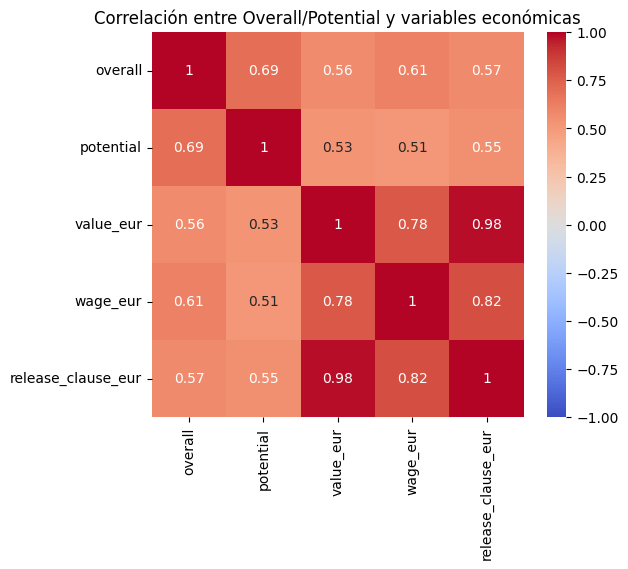

In [144]:
plt.figure(figsize=(6,5))
sns.heatmap(corr_economicas, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre Overall/Potential y variables económicas')
plt.show()

Aunque existe una relación entre habilidad y valor de mercado (un jugador con mejor overall tiende a costar más), se optó por no incluir las variables económicas en el vector de features del clustering, ya que el objetivo es agrupar por habilidades técnicas/físicas equivalentes, y el precio de mercado está influenciado por factores adicionales (edad, potencial, visibilidad mediática, equipo, escasez por posición).


In [145]:
habilidades_num = resumen_cols.loc[
    resumen_cols['categoria'].str.contains('Habilidad'), 'columna'
].tolist()

categoricas_relevantes = resumen_cols.loc[
    resumen_cols['categoria'] == 'Categórica relevante - CONSERVAR', 'columna'
].tolist()

economicas = resumen_cols.loc[
    resumen_cols['categoria'] == 'Económica (no habilidad)', 'columna'
].tolist()

id_trazabilidad = ['player_id', 'short_name', 'long_name', 'fifa_version']

columnas_finales = id_trazabilidad + categoricas_relevantes + habilidades_num + economicas
df_relevante = df[columnas_finales].copy()
print(df_relevante.shape)
df_relevante.head()

(180021, 65)


,player_id,short_name,long_name,fifa_version,club_name,club_position,international_reputation,league_level,league_name,nationality_id,nationality_name,player_positions,preferred_foot,weak_foot,work_rate,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,defending_marking_awareness,defending_sliding_tackle,defending_standing_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,mentality_aggression,mentality_composure,mentality_interceptions,mentality_penalties,mentality_positioning,mentality_vision,movement_acceleration,movement_agility,movement_balance,movement_reactions,movement_sprint_speed,power_jumping,power_long_shots,power_shot_power,power_stamina,power_strength,skill_ball_control,skill_curve,skill_dribbling,skill_fk_accuracy,skill_long_passing,skill_moves,age,defending,dribbling,height_cm,overall,pace,passing,physic,potential,shooting,weight_kg,release_clause_eur,value_eur,wage_eur
0,231747,K. Mbappé,Kylian Mbappé Lottin,24.0,Paris Saint Germain,LW,5,1.0,Ligue 1,18,France,"ST, LW",Right,4,High/Low,78,94,73,86,84,26,32,34,13,5,7,11,6,NaN,64,88.0,38,84,93,83,97,93,82,93,97,88,83,90,88,77,92,80,93,69,71,5,24,36.0,92.0,182,91,97.0,80.0,78.0,94,90.0,75,349400000.0,181500000.0,230000.0
1,239085,E. Haaland,Erling Braut Haaland,24.0,Manchester City,ST,5,1.0,Premier League,36,Norway,ST,Left,3,High/Medium,47,96,83,77,90,38,29,47,7,14,13,11,7,NaN,87,87.0,43,84,96,74,82,76,72,94,94,93,86,94,76,93,82,77,79,62,53,3,22,45.0,80.0,195,91,89.0,66.0,88.0,94,93.0,94,356100000.0,185000000.0,340000.0
2,192985,K. De Bruyne,Kevin De Bruyne,24.0,Manchester City,SUB,5,1.0,Premier League,7,Belgium,"CM, CAM",Right,5,High/Medium,95,85,55,94,83,66,53,70,15,13,5,10,13,NaN,75,88.0,66,83,88,95,72,74,78,92,72,72,92,92,88,74,92,92,86,83,94,4,32,65.0,87.0,181,91,72.0,94.0,78.0,91,88.0,75,190600000.0,103000000.0,350000.0
3,158023,L. Messi,Lionel Andrés Messi Cuccittini,24.0,Inter Miami,RF,5,1.0,Major League Soccer,52,Argentina,"CF, CAM",Left,4,Low/Low,83,89,60,91,86,20,24,35,6,11,15,14,8,NaN,44,96.0,40,75,91,92,87,91,95,88,74,71,90,83,70,68,93,93,96,93,90,4,36,33.0,94.0,169,90,80.0,90.0,64.0,90,87.0,67,61500000.0,41000000.0,23000.0
4,165153,K. Benzema,Karim Benzema,24.0,Al Ittihad,RS,5,1.0,Pro League,18,France,"CF, ST",Right,4,Medium/Medium,75,91,90,89,88,43,18,24,13,11,5,5,7,NaN,63,90.0,39,85,92,90,78,77,72,92,79,85,81,87,82,82,91,82,87,73,76,4,35,39.0,87.0,185,90,79.0,83.0,78.0,90,88.0,81,81600000.0,51000000.0,95000.0


### **1.2. b. Variación de características entre versiones.**

Se evalúa cómo varía la disponibilidad de las columnas de habilidad (`habilidades_num`) a lo largo de las 10 versiones del dataset.

El objetivo es verificar si trabajar solo con la última versión es representativo, o si alguna versión anterior aporta información complementaria.

In [146]:
# % de nulos por columna de habilidad
faltantes_por_version = (
    df_relevante
    .groupby('fifa_version')[habilidades_num]
    .apply(lambda g: g.isnull().mean() * 100)
    .round(2)
)
faltantes_por_version

,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,defending_marking_awareness,defending_sliding_tackle,defending_standing_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,mentality_aggression,mentality_composure,mentality_interceptions,mentality_penalties,mentality_positioning,mentality_vision,movement_acceleration,movement_agility,movement_balance,movement_reactions,movement_sprint_speed,power_jumping,power_long_shots,power_shot_power,power_stamina,power_strength,skill_ball_control,skill_curve,skill_dribbling,skill_fk_accuracy,skill_long_passing,skill_moves,age,defending,dribbling,height_cm,overall,pace,passing,physic,potential,shooting,weight_kg
fifa_version,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.01,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.99,10.99,0.0,0.0,10.99,10.99,10.99,0.0,10.99,0.0
16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.08,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.92,10.92,0.0,0.0,10.92,10.92,10.92,0.0,10.92,0.0
17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.67,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.33,11.33,0.0,0.0,11.33,11.33,11.33,0.0,11.33,0.0
18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.25,11.25,0.0,0.0,11.25,11.25,11.25,0.0,11.25,0.0
19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.78,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.22,11.22,0.0,0.0,11.22,11.22,11.22,0.0,11.22,0.0
20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.15,11.15,0.0,0.0,11.15,11.15,11.15,0.0,11.15,0.0
21.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.99,10.99,0.0,0.0,10.99,10.99,10.99,0.0,10.99,0.0
22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.92,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.08,11.08,0.0,0.0,11.08,11.08,11.08,0.0,11.08,0.0
23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.15,11.15,0.0,0.0,11.15,11.15,11.15,0.0,11.15,0.0


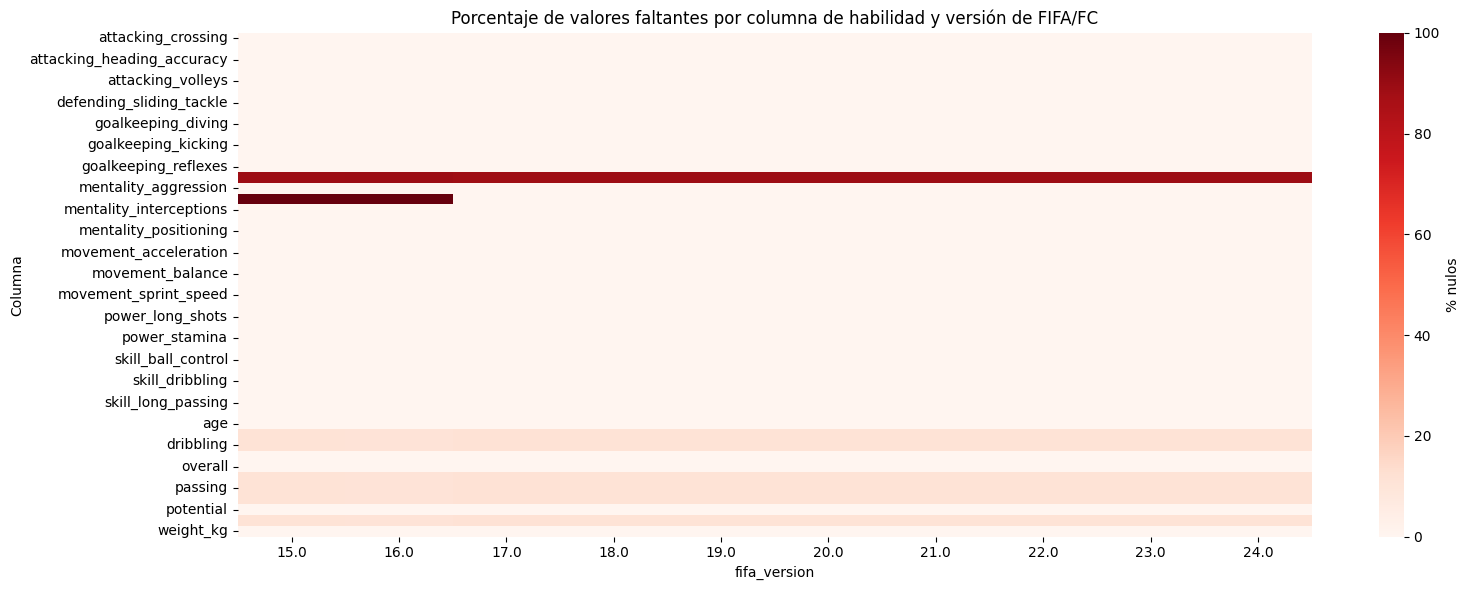

In [147]:
# Heatmap dónde se concentran los nulos
plt.figure(figsize=(16, 6))
sns.heatmap(faltantes_por_version.T, cmap='Reds', cbar_kws={'label': '% nulos'})
plt.title('Porcentaje de valores faltantes por columna de habilidad y versión de FIFA/FC')
plt.xlabel('fifa_version')
plt.ylabel('Columna')
plt.tight_layout()
plt.show()

In [148]:
# Cantidad de features utilizables
umbral = 50
features_utilizables_por_version = (faltantes_por_version < umbral).sum(axis=1)
features_utilizables_por_version.name = 'n_features_utilizables'
features_utilizables_por_version

,n_features_utilizables
fifa_version,
15.0,45
16.0,45
17.0,46
18.0,46
19.0,46
20.0,46
21.0,46
22.0,46
23.0,46


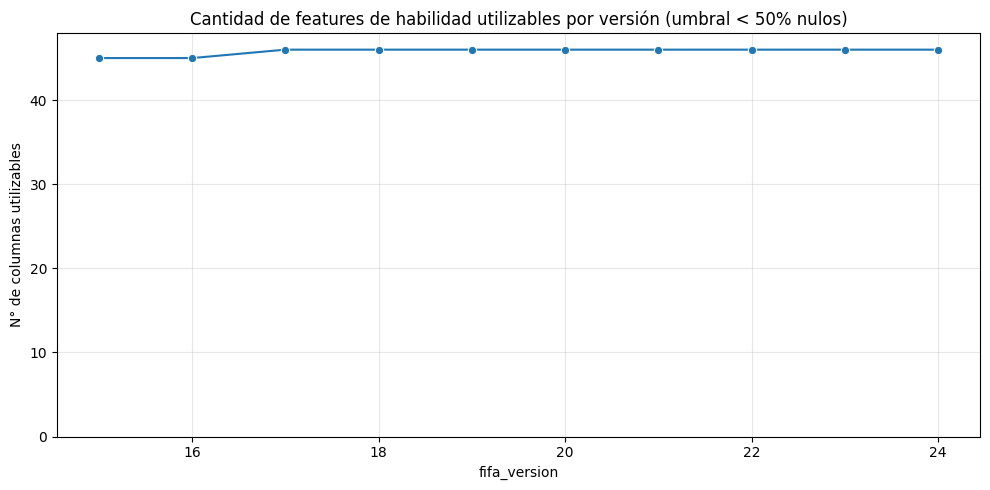

In [149]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=features_utilizables_por_version.index, y=features_utilizables_por_version.values, marker='o')
plt.title(f'Cantidad de features de habilidad utilizables por versión (umbral < {umbral}% nulos)')
plt.xlabel('fifa_version')
plt.ylabel('N° de columnas utilizables')
plt.ylim(0, len(habilidades_num) + 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [150]:
# Cantidad de jugadores por versión
jugadores_por_version = df_relevante.groupby('fifa_version')['player_id'].nunique()
jugadores_por_version

,player_id
fifa_version,
15.0,16182
16.0,16706
17.0,17596
18.0,17954
19.0,18086
20.0,18483
21.0,18892
22.0,19239
23.0,18533


In [151]:
# Evolución de los promedios a lo largo de las versiones
vars_clave = ['overall', 'potential', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

medias_por_version = df_relevante.groupby('fifa_version')[vars_clave].mean().round(2)
medias_por_version

,overall,potential,pace,shooting,passing,dribbling,defending,physic
fifa_version,,,,,,,,
15.0,63.83,68.35,68.05,51.59,55.64,60.52,49.89,64.54
16.0,65.31,70.05,68.30,52.33,56.69,61.67,50.67,64.94
17.0,66.10,70.87,68.28,52.16,56.79,61.79,50.57,64.87
18.0,66.24,71.18,67.94,52.28,57.00,62.10,50.70,64.99
19.0,66.15,71.27,67.75,52.14,56.99,62.17,51.63,64.92
20.0,66.20,71.50,67.69,52.26,57.19,62.50,51.52,64.85
21.0,65.67,71.07,67.68,52.27,57.13,62.45,51.30,64.46
22.0,65.77,71.08,68.21,52.35,57.31,62.56,51.70,64.82
23.0,65.82,70.97,68.33,52.65,57.51,62.73,51.97,64.95


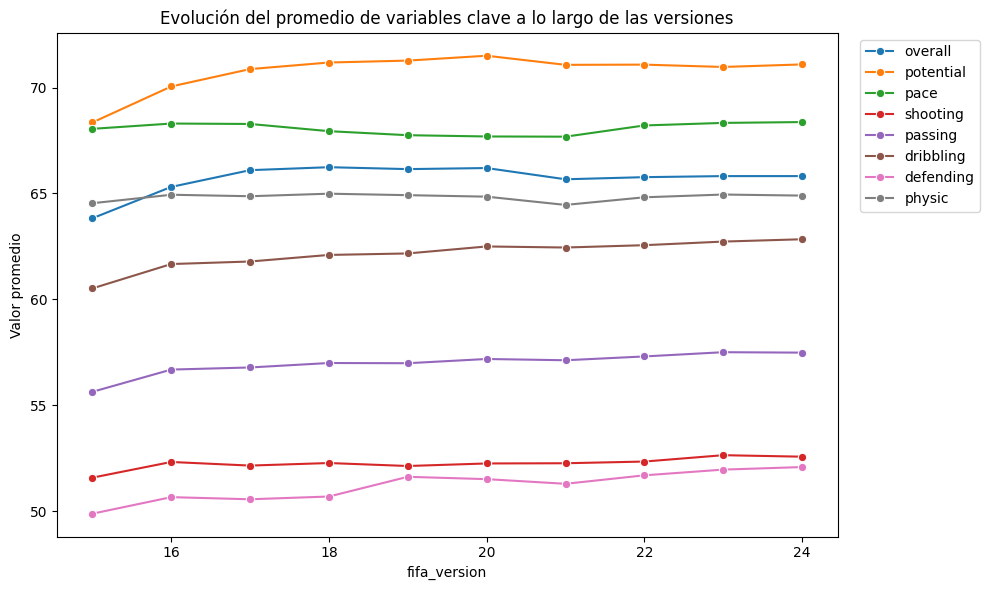

In [152]:
plt.figure(figsize=(10, 6))
for col in vars_clave:
    sns.lineplot(x=medias_por_version.index, y=medias_por_version[col], marker='o', label=col)
plt.title('Evolución del promedio de variables clave a lo largo de las versiones')
plt.xlabel('fifa_version')
plt.ylabel('Valor promedio')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Comentarios:**

Disponibilidad de columnas: las 10 versiones son  equivalentes, 45 de las 47 columnas de `habilidades_num` están completas en todas las versiones, y las dos únicas variaciones se explican por causas estructurales, `goalkeeping_speed` tiene 89% de nulos en todas las versiones por igual, y `mentality_composure` recién se incorporó al videojuego a partir de la versión 17, por lo que está nula en las versiones 15 y 16.

Se observa que FC24 tiene 46 de 47 columnas utilizables, igual que el resto de las versiones desde la v17 en adelante, no se pierde información estructural al restringir el análisis a esta versión.

Se considera que al trabajar con la versión más reciente se pierde la evolución de un mismo jugador a lo largo de las versiones, lo cual es relevante para analizar trayectorias. Pero, en este caso el objetivo del trabajo es agrupar
jugadores por habilidades equivalentes en un momento dado. Además, si bien FC24 no es la versión con mayor cantidad de jugadores, la diferencia es
marginal y no justifica sacrificar actualidad de los datos.


### **1.3. Tratamiento de valores faltantes y  duplicados**

¿Qué variables tienen missing values, en qué proporción, y qué se decidió hacer: imputar, descartar filas/columnas, etc.? y de posibles duplicados.

Como se mencionó en 1.1., el dataser combina 10 versiones del juego por jugador. Antes de analizar duplicados y valores faltantes, se filtra a la versión más reciente (FC24), de modo que cada jugador quede representado una sola vez con sus atributos actuales.

In [153]:
# Filtro de versión
df_fc24 = df_relevante[df_relevante['fifa_version'] == 24].copy()
print("Filas:", df_fc24.shape[0])
print("Jugadores únicos:", df_fc24['player_id'].nunique())

Filas: 18350
Jugadores únicos: 18350


In [154]:
# Duplicados sobre todas las columnas
print("Filas duplicadas exactas:", df_fc24.duplicated().sum())

# Duplicados por player_id
print("player_id duplicados:", df_fc24['player_id'].duplicated().sum())

Filas duplicadas exactas: 0
player_id duplicados: 0


In [155]:
# Detección de valores faltantes
faltantes = pd.DataFrame({
    'n_faltantes': df_fc24.isnull().sum(),
    'pct_faltantes': (df_fc24.isnull().mean()*100).round(2)
}).sort_values('pct_faltantes', ascending=False)

faltantes[faltantes['n_faltantes'] > 0]

,n_faltantes,pct_faltantes
goalkeeping_speed,16305,88.86
physic,2045,11.14
shooting,2045,11.14
defending,2045,11.14
dribbling,2045,11.14
pace,2045,11.14
passing,2045,11.14
release_clause_eur,1280,6.98
value_eur,100,0.54
club_position,87,0.47


In [156]:
# Causa de valores faltantes
df_fc24['es_arquero'] = df_fc24['player_positions'].str.contains('GK')

print(pd.crosstab(df_fc24['es_arquero'], df_fc24['pace'].isnull(), rownames=['es_arquero'], colnames=['pace_nulo']))
print()
print(pd.crosstab(df_fc24['es_arquero'], df_fc24['goalkeeping_speed'].isnull(), rownames=['es_arquero'], colnames=['gk_speed_nulo']))

pace_nulo   False  True 
es_arquero              
False       16305      0
True            0   2045

gk_speed_nulo  False  True 
es_arquero                 
False              0  16305
True            2045      0


In [157]:
df_fc24[df_fc24['club_name'].isnull()][['player_id','short_name','club_position','value_eur','wage_eur','overall']].head(15)

,player_id,short_name,club_position,value_eur,wage_eur,overall
440,193165,J. Corona,NaN,NaN,NaN,80
529,233260,A. Vega,NaN,NaN,NaN,79
552,222382,L. Chávez,NaN,NaN,NaN,79
636,224151,H. Martín,NaN,NaN,NaN,79
1182,235389,C. Rodríguez,NaN,NaN,NaN,76
1317,211381,S. Boufal,NaN,NaN,NaN,76
1383,234051,A. Afif,NaN,NaN,NaN,76
1507,235537,E. Sánchez,NaN,NaN,NaN,75
1518,253008,K. Álvarez,NaN,NaN,NaN,75
1539,237043,R. Alvarado,NaN,NaN,NaN,75


In [158]:
# Imputación
skills_campo = ['pace','shooting','passing','dribbling','defending','physic']
df_fc24[skills_campo] = df_fc24[skills_campo].fillna(0)
df_fc24['goalkeeping_speed'] = df_fc24['goalkeeping_speed'].fillna(0)

for col in ['club_name','club_position','league_name']:
    df_fc24[col] = df_fc24[col].fillna('Sin club')
df_fc24['league_level'] = df_fc24['league_level'].fillna(0)
df_fc24['wage_eur'] = df_fc24['wage_eur'].fillna(0)

print(df_fc24.isnull().sum()[df_fc24.isnull().sum() > 0])

release_clause_eur    1280
value_eur              100
dtype: int64


Tras filtrar la base a la versión FC24, se detectaron valores faltantes concentrados en dos grupos con causas estructurales:

- Los atributos pace,shooting,passing,dribbling,defending,physic faltan en los 2.045 arqueros de la base, mientras que goalkeeping_speed falta en los 16.305 jugadores de campo, hay correspondencia con la variable player_positions, por lo que el missing no representa un error de carga. Se imputó con 0 en ambos casos.

- 87 jugadores presentan club_name, club_position, league_name y wage_eur faltantes, se observó que no son jugadores marginales (varios con overall entre 74-80), por lo que se optó por imputar la categoría "Sin club" en vez de descartar esas filas.

Las variables económicas value_eur (0.54%) y release_clause_eur (6.98%) mantienen missing sin tratar, al no formar parte del vector de features del clustering.

### **1.4. Distribución de las principales variables categóricas: posición, liga y nacionalidad.**

Posición: player_position

Esta columna trae múltiples posiciones por jugador separadas por come, se mira la posición principal como el conteo de combinaciones.

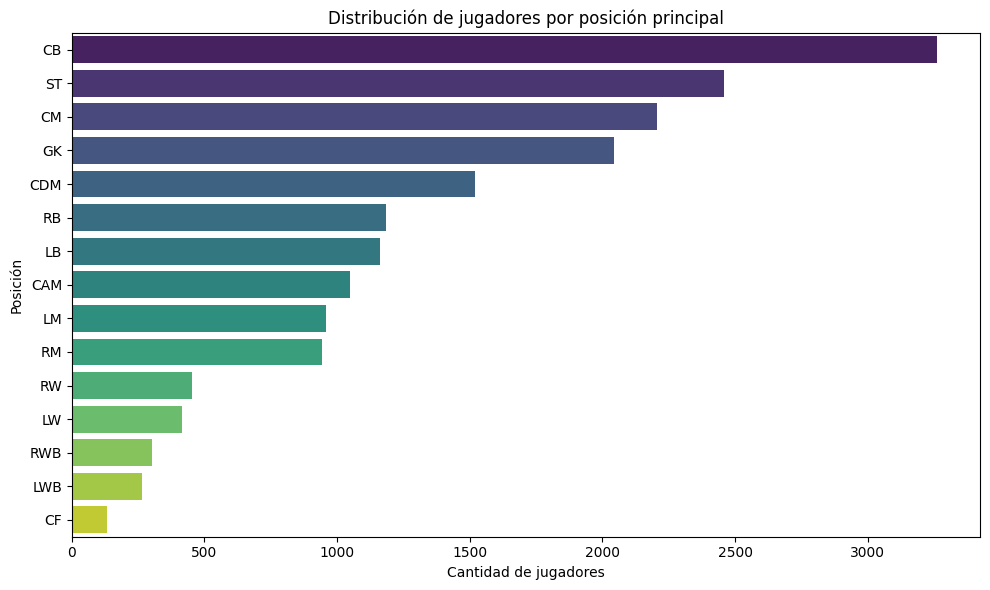

In [159]:
# Posición principal
df_fc24['posicion_principal'] = df_fc24['player_positions'].str.split(',').str[0]

plt.figure(figsize=(10,6))
orden = df_fc24['posicion_principal'].value_counts().index
sns.countplot(y='posicion_principal', data=df_fc24, order=orden, palette='viridis')
plt.title('Distribución de jugadores por posición principal')
plt.xlabel('Cantidad de jugadores')
plt.ylabel('Posición')
plt.tight_layout()
plt.show()

In [160]:
df_fc24['posicion_principal'].value_counts()

,count
posicion_principal,
CB,3260
ST,2457
CM,2204
GK,2045
CDM,1519
RB,1186
LB,1162
CAM,1049
LM,957


Hay más defensores centrales (CB) que cualquier otra posición seguido de delanteros (ST), y volantes centrales (CM), tiene sentido porque los equipos suelen tener 2-3 CB pero 1 arquero titular.

Liga (league_mean)

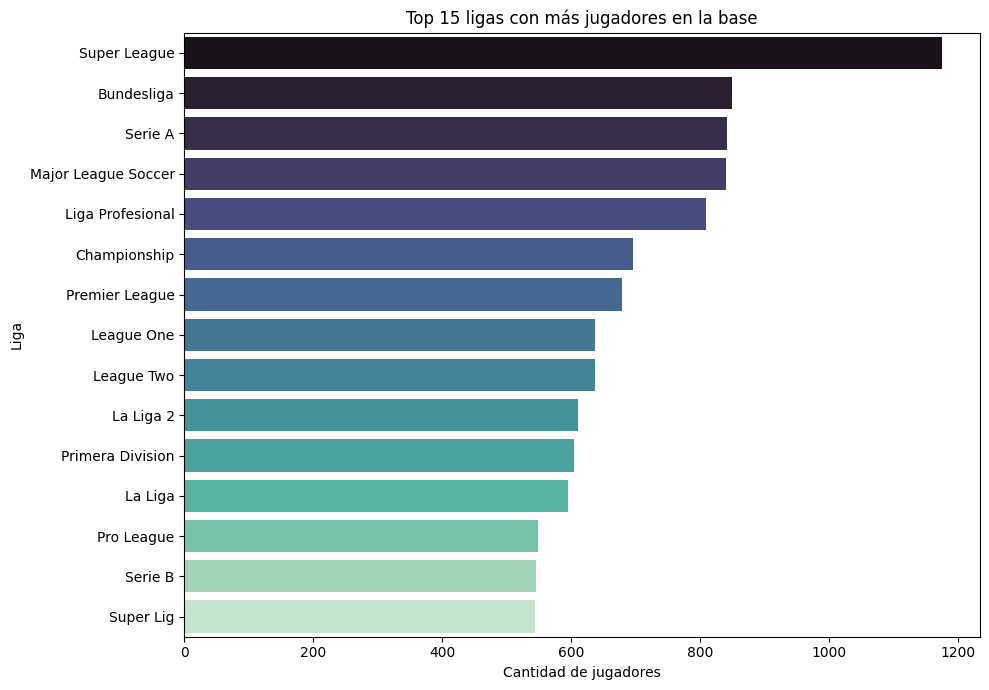

In [161]:
top_ligas = df_fc24['league_name'].value_counts().head(15)

plt.figure(figsize=(10,7))
sns.barplot(x=top_ligas.values, y=top_ligas.index, palette='mako')
plt.title('Top 15 ligas con más jugadores en la base')
plt.xlabel('Cantidad de jugadores')
plt.ylabel('Liga')
plt.tight_layout()
plt.show()

La distribución se encuentra repartida entre las top 15, liderando Super League, seguida de Bundesliga y Serie A.

Ninguna liga concentra desprorpocionadamente la base, lo cual es bueno para que el clustering no esté sesgado.

Nacionalidad (nationality_name)

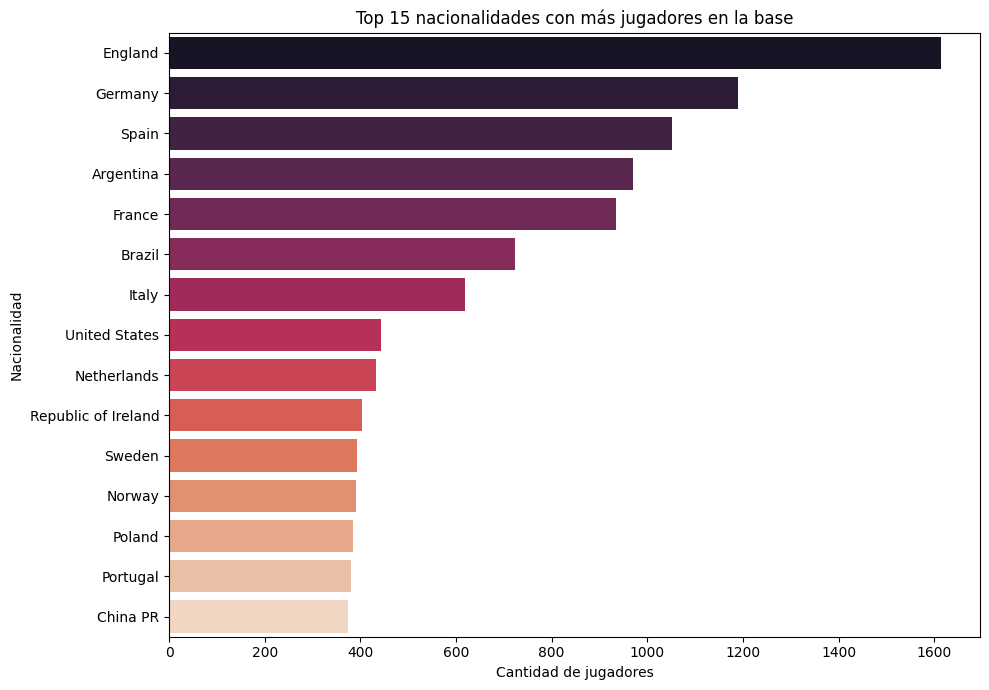

In [162]:
top_nac = df_fc24['nationality_name'].value_counts().head(15)

plt.figure(figsize=(10,7))
sns.barplot(x=top_nac.values, y=top_nac.index, palette='rocket')
plt.title('Top 15 nacionalidades con más jugadores en la base')
plt.xlabel('Cantidad de jugadores')
plt.ylabel('Nacionalidad')
plt.tight_layout()
plt.show()

Inglaterra lidera, seguida de Alemania y España. Inglaterra lidera ya que tiene muchisímas divisiones en el dataset.

Pie hábil (preferred_foot)


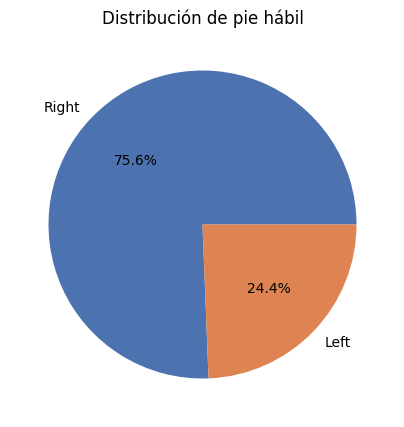

In [163]:
plt.figure(figsize=(5,5))
df_fc24['preferred_foot'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4C72B0','#DD8452'])
plt.title('Distribución de pie hábil')
plt.ylabel('')
plt.show()

Distribución de edad

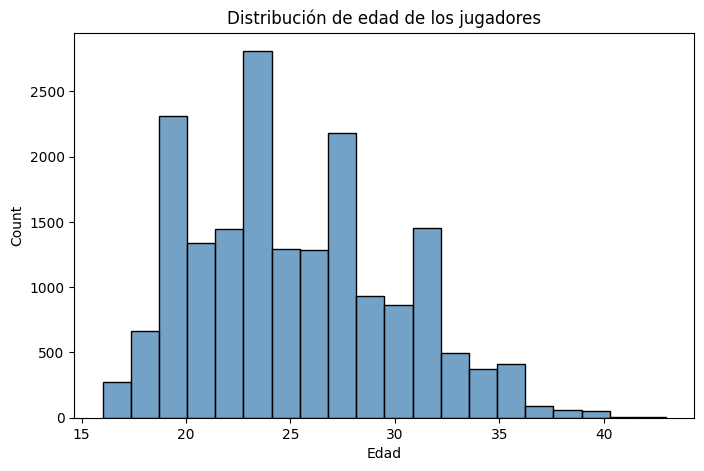

In [164]:
plt.figure(figsize=(8,5))
sns.histplot(df_fc24['age'], bins=20, color='steelblue')
plt.title('Distribución de edad de los jugadores')
plt.xlabel('Edad')
plt.show()

Ritmo de trabajo ataque / defensa

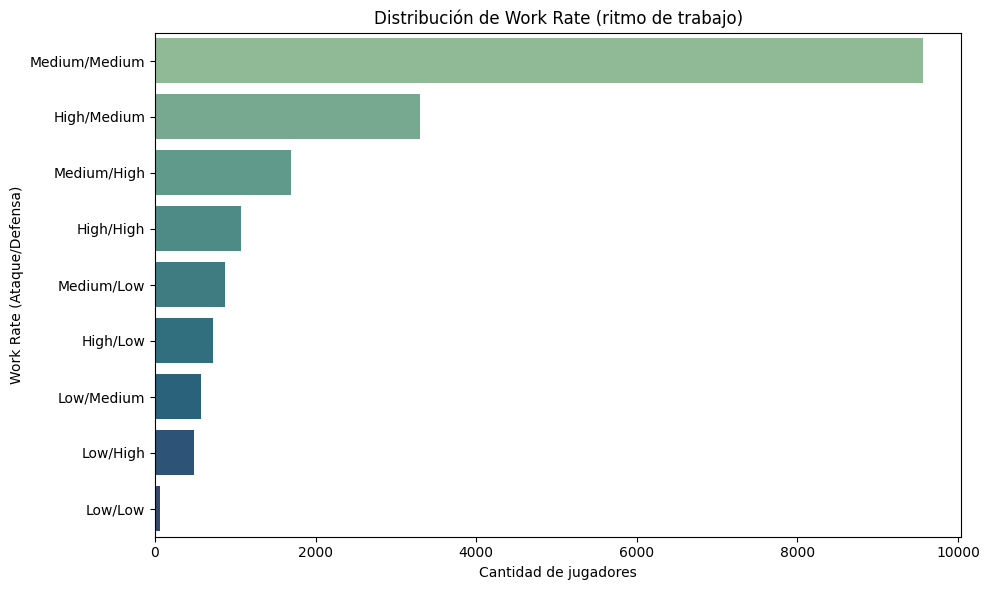

In [165]:
plt.figure(figsize=(10,6))
orden_wr = df_fc24['work_rate'].value_counts().index
sns.countplot(y='work_rate', data=df_fc24, order=orden_wr, palette='crest')
plt.title('Distribución de Work Rate (ritmo de trabajo)')
plt.xlabel('Cantidad de jugadores')
plt.ylabel('Work Rate (Ataque/Defensa)')
plt.tight_layout()
plt.show()

Habilidad de trucos

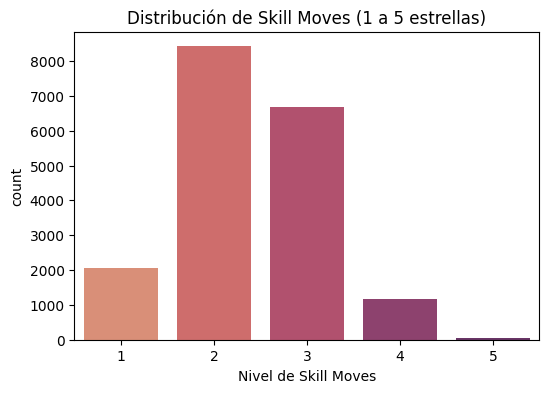

In [166]:
plt.figure(figsize=(6,4))
sns.countplot(x='skill_moves', data=df_fc24, palette='flare')
plt.title('Distribución de Skill Moves (1 a 5 estrellas)')
plt.xlabel('Nivel de Skill Moves')
plt.show()

### **1.5.Estadística descriptiva de las variables numéricas relevantes**

 Medidas de tendencia central y dispersión, señalando casos llamativos (rangos inesperados, asimetrías fuertes, outliers evidentes).

In [167]:
# Estadística descriptiva  de las variables numéricas de habilidad
vars_numericas = habilidades_num

desc = df_fc24[vars_numericas].describe().T
desc['rango'] = desc['max'] - desc['min']
desc['asimetria'] = df_fc24[vars_numericas].skew()
desc.sort_values('asimetria', ascending=False)

,count,mean,std,min,25%,50%,75%,max,rango,asimetria
goalkeeping_speed,18350.0,3.928828,11.643554,0.0,0.0,0.0,0.0,65.0,65.0,2.900856
goalkeeping_positioning,18350.0,16.168392,17.093683,2.0,8.0,11.0,14.0,90.0,88.0,2.462836
goalkeeping_reflexes,18350.0,16.423815,17.880726,2.0,8.0,11.0,14.0,93.0,91.0,2.455528
goalkeeping_diving,18350.0,16.329373,17.572154,2.0,8.0,11.0,14.0,90.0,88.0,2.442322
goalkeeping_kicking,18350.0,16.035095,16.699136,2.0,8.0,11.0,14.0,91.0,89.0,2.439738
goalkeeping_handling,18350.0,16.124578,16.945031,2.0,8.0,11.0,14.0,90.0,88.0,2.434709
age,18350.0,25.267139,4.757756,16.0,21.0,25.0,29.0,43.0,27.0,0.430294
weight_kg,18350.0,75.210354,6.985703,49.0,70.0,75.0,80.0,105.0,56.0,0.217437
skill_moves,18350.0,2.386594,0.775725,1.0,2.0,2.0,3.0,5.0,4.0,0.152965
potential,18350.0,71.088065,6.220982,48.0,67.0,71.0,75.0,94.0,46.0,0.094918


In [168]:
# Resumen de variables
resumen_vars = ['overall','potential','age','height_cm','weight_kg','pace','shooting','passing','dribbling','defending','physic']
df_fc24[resumen_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
overall,18350.0,65.817057,6.817917,47.0,62.0,66.0,70.0,91.0
potential,18350.0,71.088065,6.220982,48.0,67.0,71.0,75.0,94.0
age,18350.0,25.267139,4.757756,16.0,21.0,25.0,29.0,43.0
height_cm,18350.0,181.698747,6.869995,156.0,177.0,182.0,187.0,206.0
weight_kg,18350.0,75.210354,6.985703,49.0,70.0,75.0,80.0,105.0
pace,18350.0,60.752153,23.789454,0.0,58.0,68.0,75.0,97.0
shooting,18350.0,46.722125,21.106931,0.0,35.0,52.0,62.0,93.0
passing,18350.0,51.082943,20.355752,0.0,47.0,56.0,63.0,94.0
dribbling,18350.0,55.836403,21.688271,0.0,54.0,62.0,68.0,94.0
defending,18350.0,46.287956,22.292462,0.0,31.0,54.0,63.0,89.0


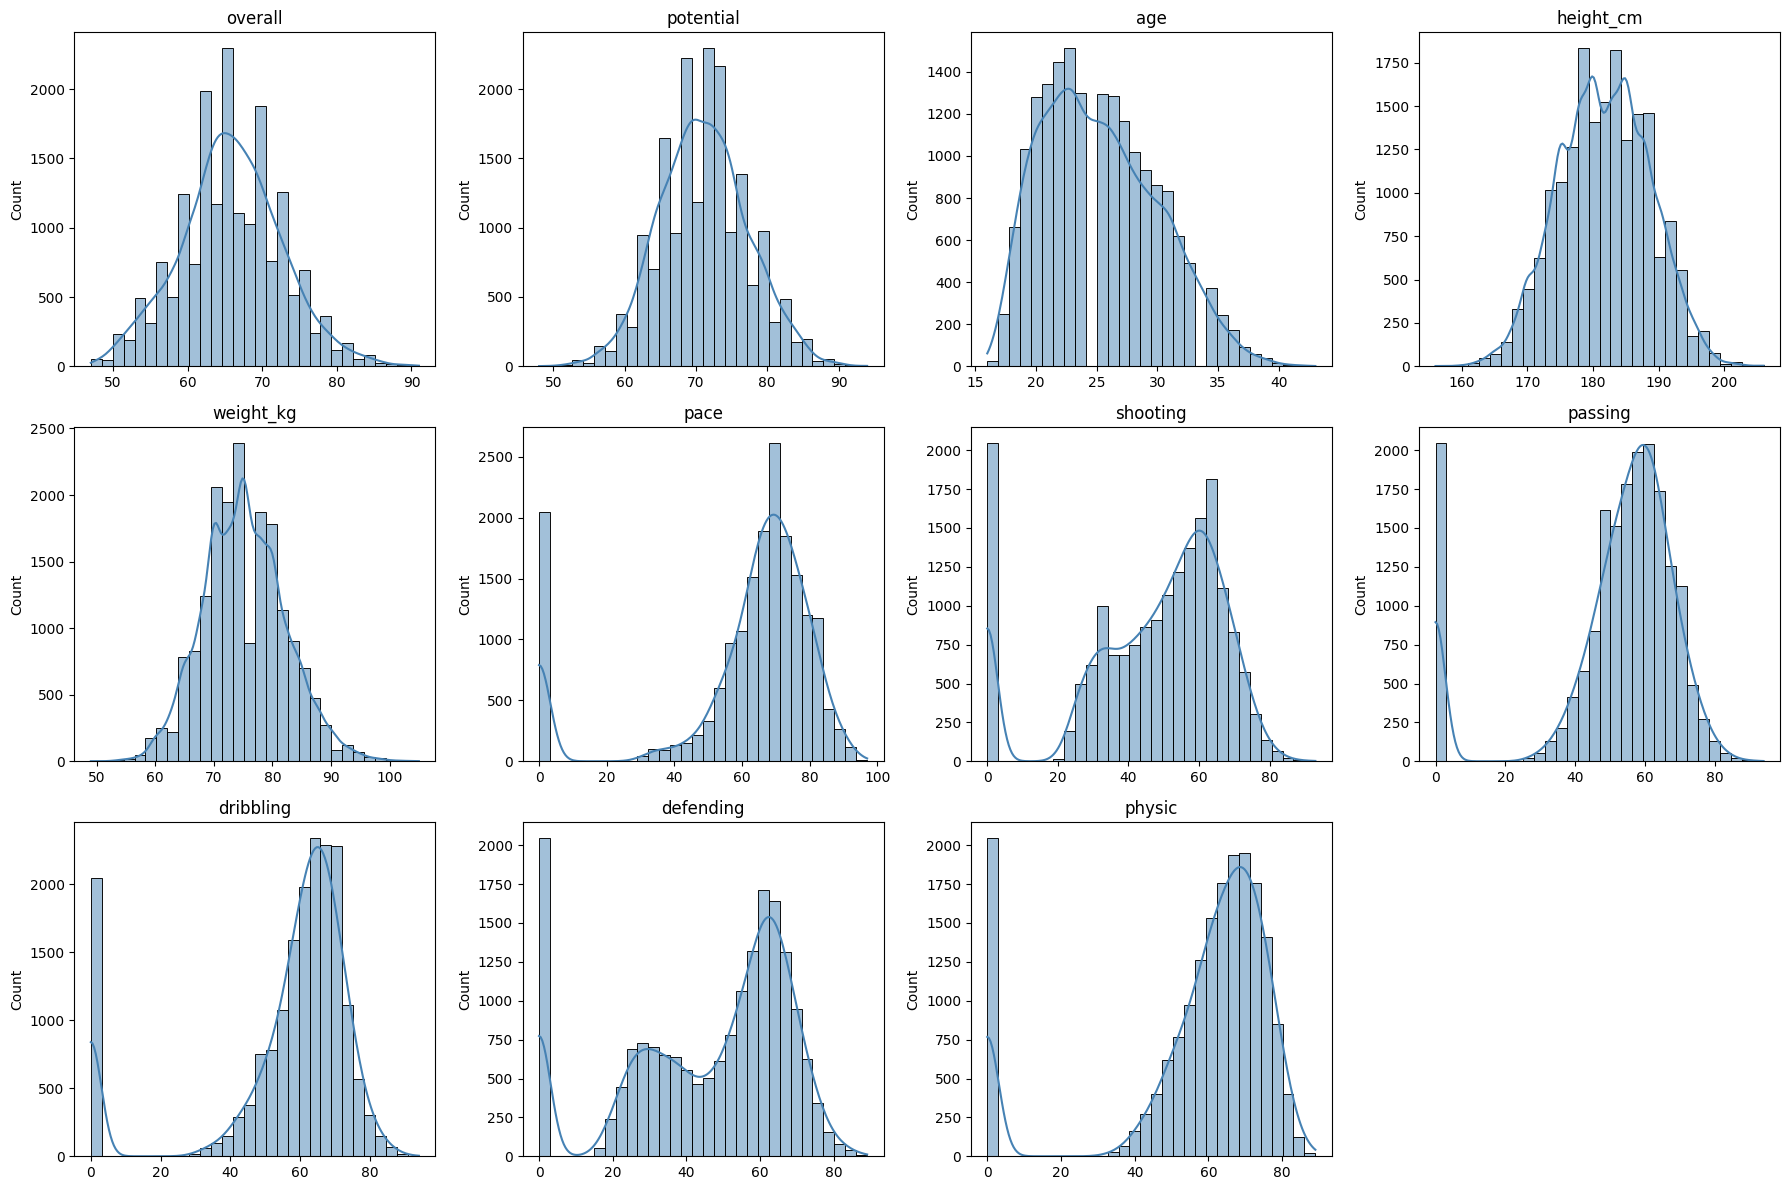

In [169]:
# Histogramas de las variables numéricas resumen (grilla de subplots)
resumen_vars = ['overall','potential','age','height_cm','weight_kg','pace','shooting','passing','dribbling','defending','physic']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(resumen_vars):
    sns.histplot(df_fc24[col], bins=30, ax=axes[i], color='steelblue', kde=True)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Ocultamos el subplot vacío (11 variables en grilla de 12)
axes[-1].axis('off')

plt.tight_layout()
plt.show()

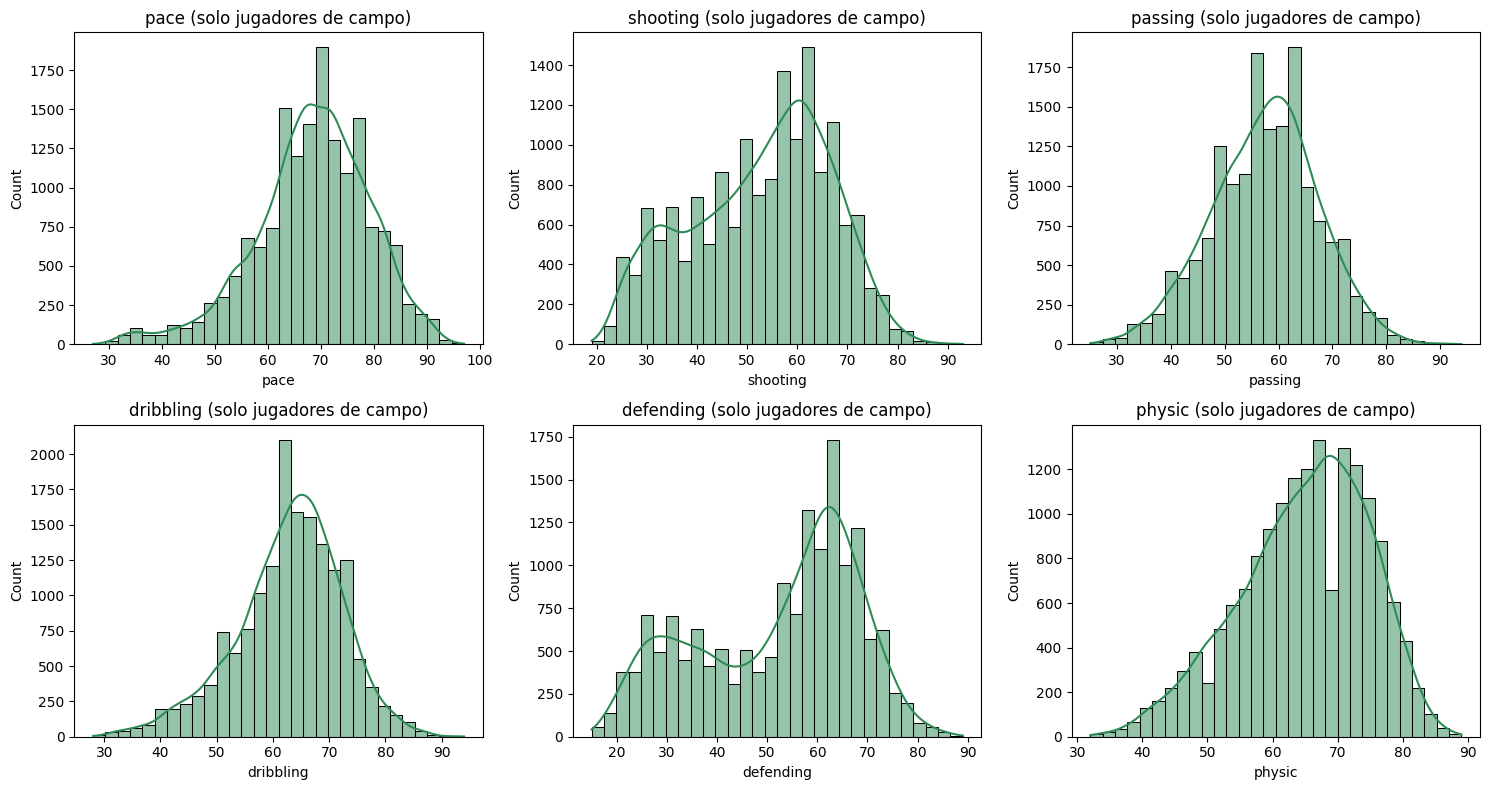

In [170]:
# Histogramas de skills de campo, excluyendo arqueros
skills_campo = ['pace','shooting','passing','dribbling','defending','physic']
df_campo = df_fc24[~df_fc24['es_arquero']]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(skills_campo):
    sns.histplot(df_campo[col], bins=30, ax=axes[i], color='seagreen', kde=True)
    axes[i].set_title(f'{col} (solo jugadores de campo)')

plt.tight_layout()
plt.show()

In [171]:
# Comparamos asimetría con y sin el pico artificial de arqueros
print("Skewness INCLUYENDO arqueros (con 0 imputado):")
print(df_fc24[skills_campo].skew())
print("\nSkewness EXCLUYENDO arqueros:")
print(df_campo[skills_campo].skew())

Skewness INCLUYENDO arqueros (con 0 imputado):
pace        -1.698193
shooting    -0.940457
passing     -1.550322
dribbling   -1.744204
defending   -0.770515
physic      -1.722565
dtype: float64

Skewness EXCLUYENDO arqueros:
pace        -0.557836
shooting    -0.281797
passing     -0.145725
dribbling   -0.483644
defending   -0.445871
physic      -0.443001
dtype: float64


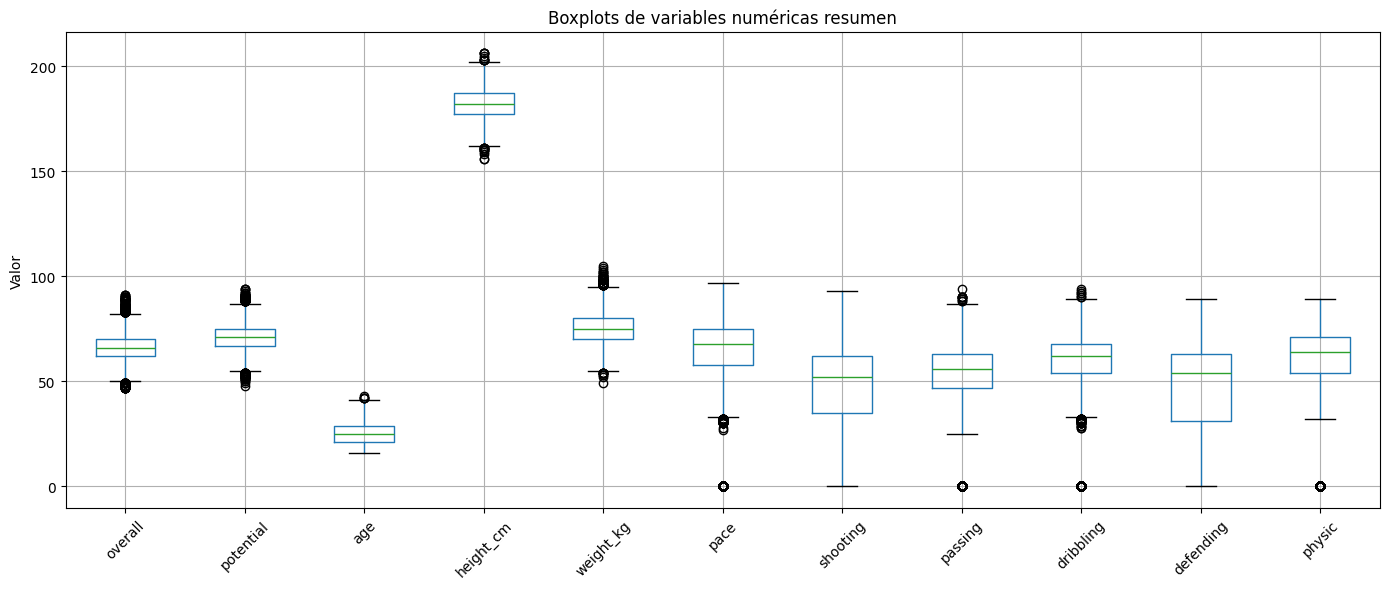

In [172]:
# Visualización de outliers: boxplots de las variables resumen
plt.figure(figsize=(14,6))
df_fc24[resumen_vars].boxplot(rot=45)
plt.title('Boxplots de variables numéricas resumen')
plt.ylabel('Valor')
plt.tight_layout()
plt.show()

In [173]:
# Caso 1: jugadores con valores extremos de edad
print("Jugador más joven:")
print(df_fc24.loc[df_fc24['age'].idxmin(), ['short_name','age','overall','club_name']])
print("\nJugador más grande:")
print(df_fc24.loc[df_fc24['age'].idxmax(), ['short_name','age','overall','club_name']])

Jugador más joven:
short_name    G. Ilenikhena
age                      16
overall                  61
club_name           Antwerp
Name: 13801, dtype: object

Jugador más grande:
short_name        S. Lukić
age                     43
overall                 61
club_name     Varberg BoIS
Name: 14451, dtype: object


In [174]:
# Caso 2: extremos de altura/peso
print(df_fc24.nsmallest(5, 'height_cm')[['short_name','height_cm','weight_kg','player_positions']])
print()
print(df_fc24.nlargest(5, 'height_cm')[['short_name','height_cm','weight_kg','player_positions']])

        short_name  height_cm  weight_kg player_positions
1952    N. Barrios        156         58          LW, CAM
8325      B. Oyola        156         58      RM, RW, CAM
8731     J. Nisbet        158         58           CM, RM
1610    M. Moralez        159         54      CAM, CM, CF
4994  V. Hernández        160         59      LM, CAM, RM

        short_name  height_cm  weight_kg player_positions
4337      I. Touré        206         98               CB
13621      T. Holý        206        102               GK
15971  K. Gadellaa        206         92               GK
16119    K. Hudlin        206         85               ST
16323  T. Hülsmann        205         89               GK


El overall muestra una distribución simétrica centrada en 65-67, mientras que age presenta asimetría positiva, debido a una población joven con algunos casos extendidos.

Las variables pace, shooting, passing, dribbling, defending y physic mostraron inicialmente una asimetría fuerte debido a un pico artificial en 0, producto de la imputación de arqueros en 1.3. Al excluirlos, la asimetría se reduce notablemente (entre -0.15 y -0.56), confirmando que no era un patrón real. La excepción es defending, que conserva cierta bimodalidad genuina entre perfiles ofensivos y defensivos.

Casos llamativos: el jugador más joven es G. Ilenikhena (16 años, Overall 61) y el mayor S. Lukić (43 años, Overall 61). En altura, los extremos también son coherentes con la posición: los más bajos (156 cm) juegan de LW/CAM, y los más altos (205-206 cm) son CB/GK.

## **2. Evaluación visual e intuitiva de dos a dos variables numéricas por vez.**

Sugerencia: hagan los scatterplots de las combinaciones de dos variables que tengan algún sentido para ustedes, porque todas las combinaciones de variables son muchas y no van a poder analizarlas como merecen.



Se seleccionaron pares de variables con sentido futbolístico o analítico, agrupados en tres motivaciones:
- Pares esperablemente correlacionados por representar habilidades del mismo "tipo" de jugador.
- Pares esperablemente en tensión/trade-off entre sí, y
- Variables resumen vs. variables físicas o de contexto (edad, altura).

In [175]:
# Función auxiliar
def scatter_pair(x, y, hue=None, sample=None, alpha=0.4):
    data = df_campo if sample is None else df_campo.sample(sample, random_state=42)
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=x, y=y, hue=hue, data=data, alpha=alpha, palette='viridis' if hue else None)
    plt.title(f'{y} vs {x}' + (f' (coloreado por {hue})' if hue else ''))
    plt.tight_layout()
    plt.show()

Se usa df_campo sin arqueros para estos pares porque son variables de habilidad de campo.

1) attacking_finishing vs attacking_heading_accuracy: como son ambas de definición ¿van juntas o habilidades distintas?


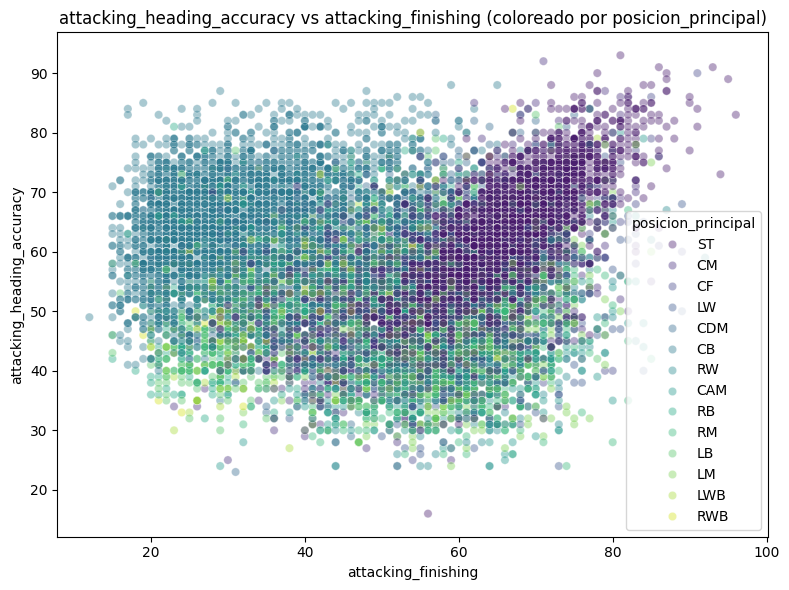

In [176]:
scatter_pair('attacking_finishing', 'attacking_heading_accuracy', hue='posicion_principal')

2. pace vs defending: delanteros rápidos vs defensores

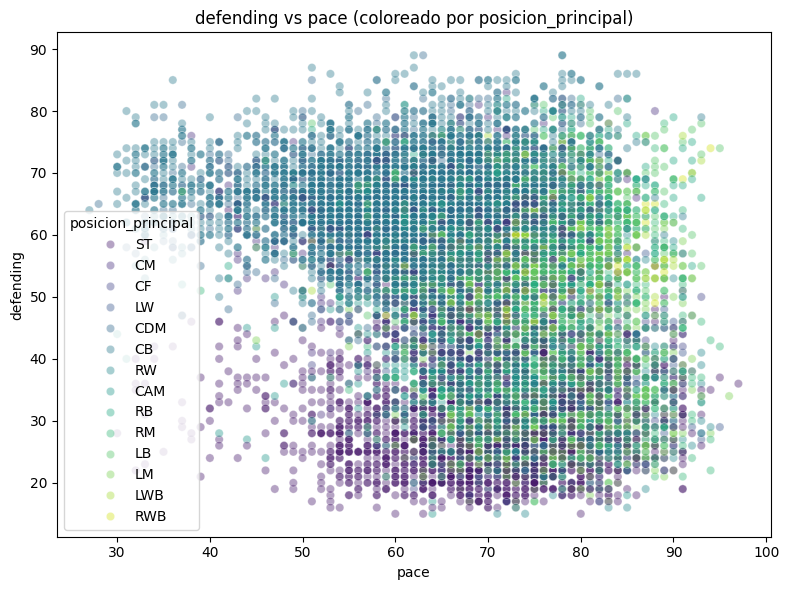

In [177]:
scatter_pair('pace', 'defending', hue='posicion_principal')

3. dribbling vs defending_standing_tackle: habilidad ofensiva vs habilidad defensida, tensión esperada

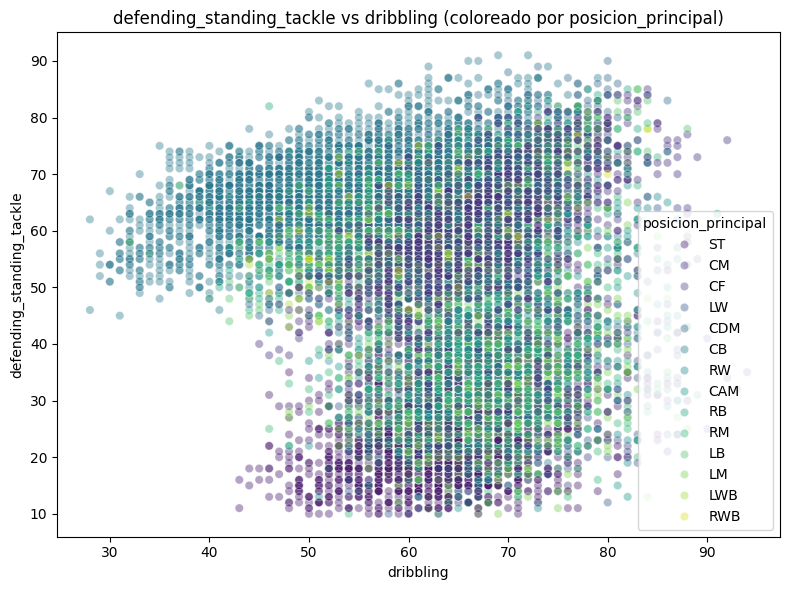

In [178]:
scatter_pair('dribbling', 'defending_standing_tackle', hue='posicion_principal')

4. overall vs age: ¿a qué edad se alcanza el pico de rendimiento?

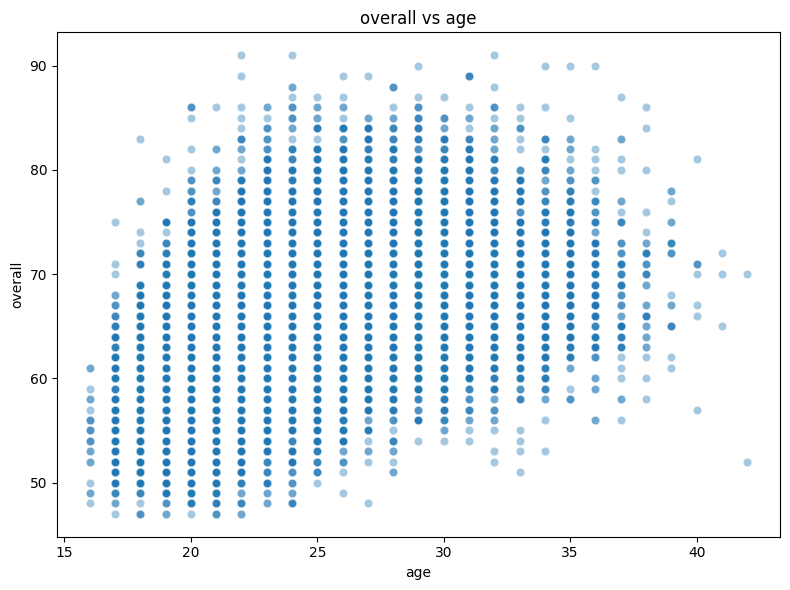

In [179]:
scatter_pair('age', 'overall', sample=None)  # sobre df_campo; si querés todos los jugadores, cambiá a df_fc24

5. potential vs age: ¿los jóvenes tienen mayor margen de crecimiento?

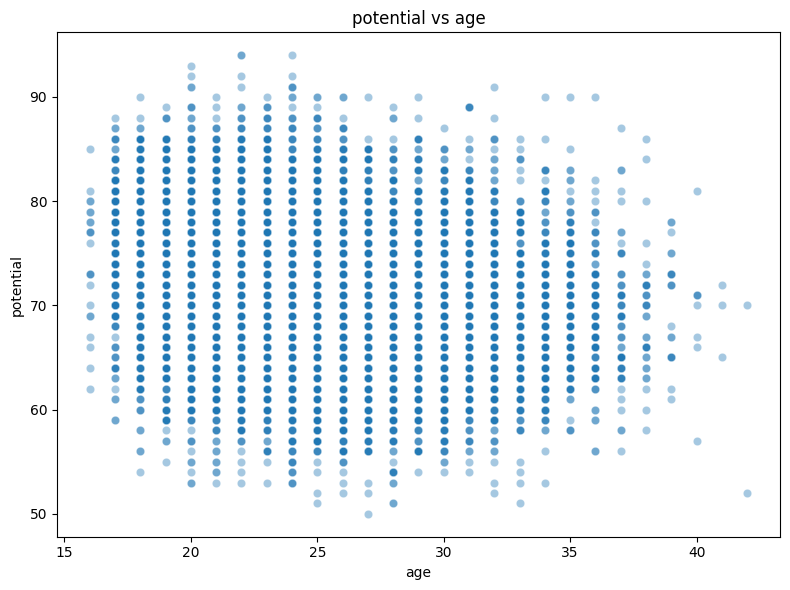

In [180]:
scatter_pair('age', 'potential')

6. height_cm vs mentality_agression: físico vs estilo de juego, ¿hay relación?

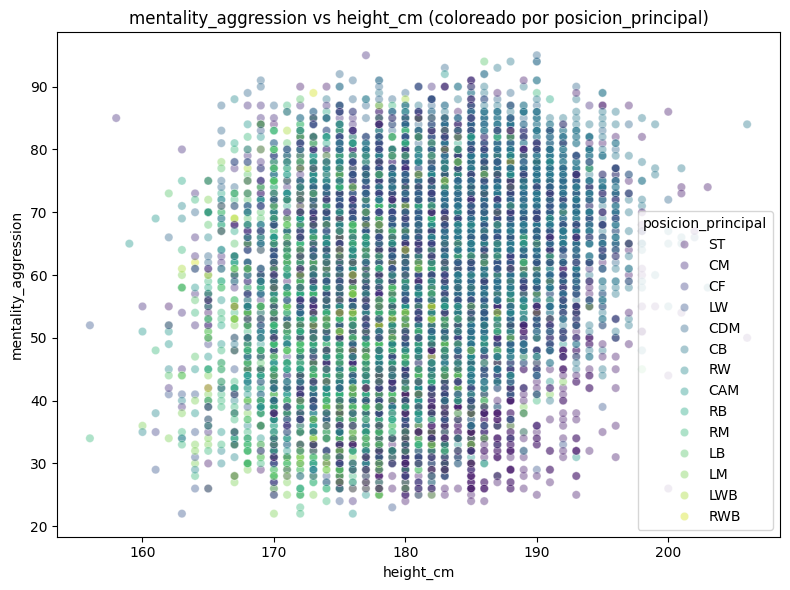

In [181]:
scatter_pair('height_cm', 'mentality_aggression', hue='posicion_principal')

Los pares muestran distintos tipos de relación: fuerte trade-off posicional en pace vs defending y dribbling vs defending_standing_tackle (dos nubes/forma en V); relación no lineal en overall vs age (pico de rendimiento 28-31 años) y potential vs age (decreciente, el margen de crecimiento se agota con la edad).

Correlación positiva moderada en attacking_finishing vs attacking_heading_accuracy; y ausencia de relación en mentality_aggression vs height_cm. Estos patrones son un buen indicio de que existen agrupamientos naturales de jugadores por perfil de juego, lo cual motiva y justifica el análisis de clustering de las secciones siguientes.

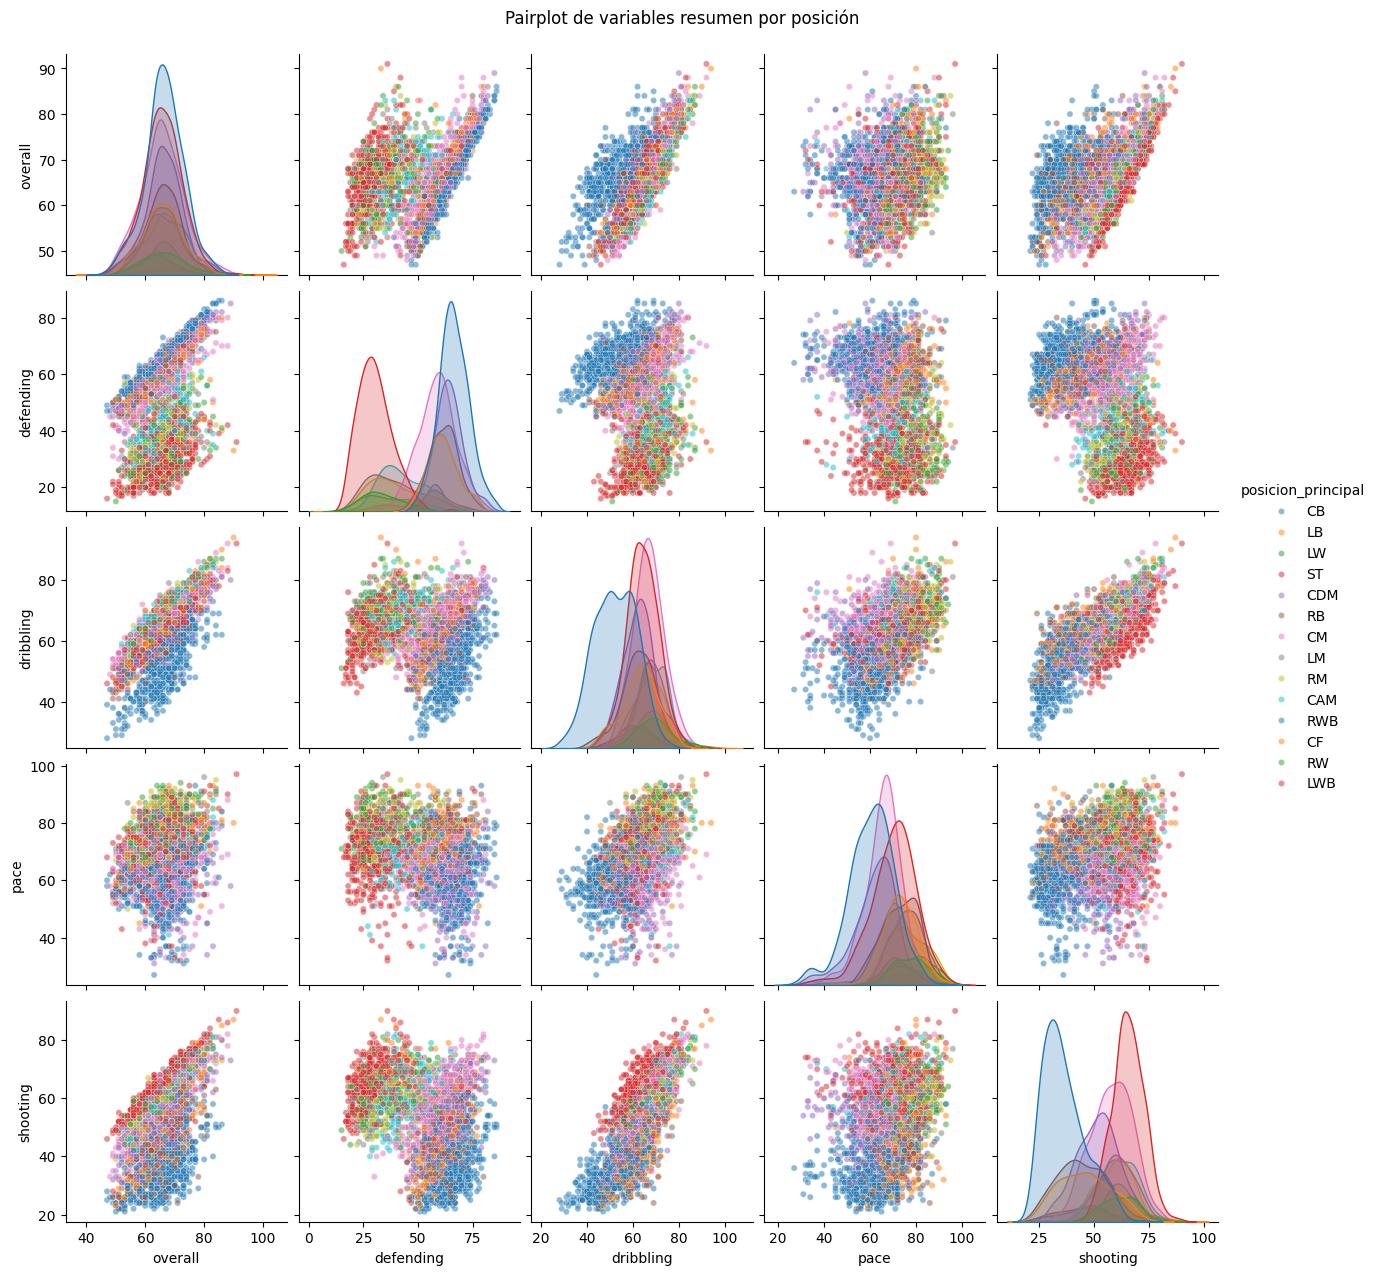

In [182]:
resumen_vars_pos = ['overall', 'defending', 'dribbling', 'pace', 'shooting']

# Se usa una muestra por costo computacional del pairplot
muestra_pairplot = df_campo.sample(3000, random_state=42)

sns.pairplot(muestra_pairplot, vars=resumen_vars_pos, hue='posicion_principal',
             palette='tab10', diag_kind='kde', plot_kws={'alpha':0.5, 's':20})
plt.suptitle('Pairplot de variables resumen por posición', y=1.02)
plt.show()

Se observa que los extremos del campo se distinguen con claridad, pero el centro se mezcla.

- **CB (azul)**: forma la nube más separada del resto, valores bajos de `dribbling` y
  `shooting`, altos de `defending`, es la
  posición "independiente" del dataset.
- **ST (rojo)**: es el otro extremo bien diferenciado, alto `shooting` y `dribbling`, bajo `defending`.
- **Las posiciones de mitad de cancha (CM, CDM, CAM, LM, RM, CDM)**: se superponen en casi todos los pares, no hay separación visual clara entre ellas. Son roles que comparten ataque y defensa.
- **`pace`**: es la variable que menos separa por posición, su distribución en la diagonal
  es la más solapada entre todos los colores.
- `overall` conserva la forma de embudo con todas las demás variables, hay jugadores
  de overall bajo en todo el rango de las otras variables. Los de overall alto tienden
  a concentrarse en valores altos también de `dribbling` y `shooting`.

Este patrón indica que no conviene utilizar la etiqueta de posición, ya que la posición formal no captura del todo la similitud real de perfiles, sobre todo
en el mediocampo.

### **2.7. Selección de población para clustering**



Se opta por un agrupamiento en 3 roles porque el pairplot anterior mostró que las posiciones de mediocampo no se distinguen con claridad entre sí. Esta categoría se usa para filtrar la población y para la interpretación de clusters, no como variable de entrada al algoritmo de clustering.

In [183]:
# Se recategoriza posicion_principal
delanteros = ['ST','CF','LW','RW','LF','RF','LS','RS']
volantes    = ['CM','CDM','CAM','LM','RM','LCM','RCM','LDM','RDM','LAM','RAM']
defensores  = ['CB','LB','RB','LWB','RWB','LCB','RCB']

def categoria_posicion(pos):
    if pos in delanteros:
        return 'Delantero'
    elif pos in volantes:
        return 'Volante'
    elif pos in defensores:
        return 'Defensor'
    else:
        return 'Intermedia/Otra'

df_campo['categoria_posicion'] = df_campo['posicion_principal'].apply(categoria_posicion)
df_campo['categoria_posicion'].value_counts()

,count
categoria_posicion,
Volante,6673
Defensor,6174
Delantero,3458


In [184]:
for umbral_test in [55, 60, 65]:
    sub = df_campo[df_campo['overall'] >= umbral_test]
    n = sub.shape[0]
    # dispersión promedio de las skills de campo (cuán "diferenciados" son los perfiles)
    disp = sub[['pace','shooting','passing','dribbling','defending','physic']].std().mean()
    print(f"umbral={umbral_test}: n={n} ({n/df_campo.shape[0]*100:.1f}%), dispersión media de skills={disp:.2f}")

umbral=55: n=15489 (95.0%), dispersión media de skills=11.43
umbral=60: n=13766 (84.4%), dispersión media de skills=11.27
umbral=65: n=9649 (59.2%), dispersión media de skills=11.19


In [185]:
umbral_overall = 55

df_cluster_pop = df_campo[
    (df_campo['categoria_posicion'] != 'Intermedia/Otra') &
    (df_campo['overall'] >= umbral_overall)
].copy()

print("Filas antes del filtro:", df_campo.shape[0])
print("Filas después del filtro:", df_cluster_pop.shape[0])
df_cluster_pop['categoria_posicion'].value_counts()

Filas antes del filtro: 16305
Filas después del filtro: 15489


,count
categoria_posicion,
Volante,6346
Defensor,5854
Delantero,3289


### **2.8. Agrupación de variables y análisis de redundancia**


In [186]:
habilidades_num_campo = [c for c in habilidades_num if c != 'goalkeeping_speed']

def clasificar_familia(col):
    prefijos = {
        'attacking_':   'Ataque',
        'skill_':       'Técnica/Skill',
        'movement_':    'Movimiento',
        'power_':       'Físico/Power',
        'mentality_':   'Mentalidad',
        'defending_':   'Defensa',
        'goalkeeping_': 'Portería',
    }
    for prefijo, fam in prefijos.items():
        if col.startswith(prefijo):
            return fam
    if col in ['age', 'height_cm', 'weight_kg']:
        return 'Física'
    if col in ['overall', 'potential', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']:
        return 'Resumen global'
    return 'Otras / sin clasificar'

familias_df = pd.DataFrame({
    'columna': habilidades_num_campo,
    'familia': [clasificar_familia(c) for c in habilidades_num_campo]
})

print(familias_df['familia'].value_counts())

# Chequeo no debería haber nada sin clasificar
sin_clasificar = familias_df.loc[familias_df['familia'] == 'Otras / sin clasificar', 'columna'].tolist()
assert len(sin_clasificar) == 0, f"Hay columnas sin clasificar, revisar: {sin_clasificar}"

familias_df

familia
Resumen global    8
Técnica/Skill     6
Mentalidad        6
Ataque            5
Portería          5
Físico/Power      5
Movimiento        5
Defensa           3
Física            3
Name: count, dtype: int64


,columna,familia
0,attacking_crossing,Ataque
1,attacking_finishing,Ataque
2,attacking_heading_accuracy,Ataque
3,attacking_short_passing,Ataque
4,attacking_volleys,Ataque
5,defending_marking_awareness,Defensa
6,defending_sliding_tackle,Defensa
7,defending_standing_tackle,Defensa
8,goalkeeping_diving,Portería
9,goalkeeping_handling,Portería


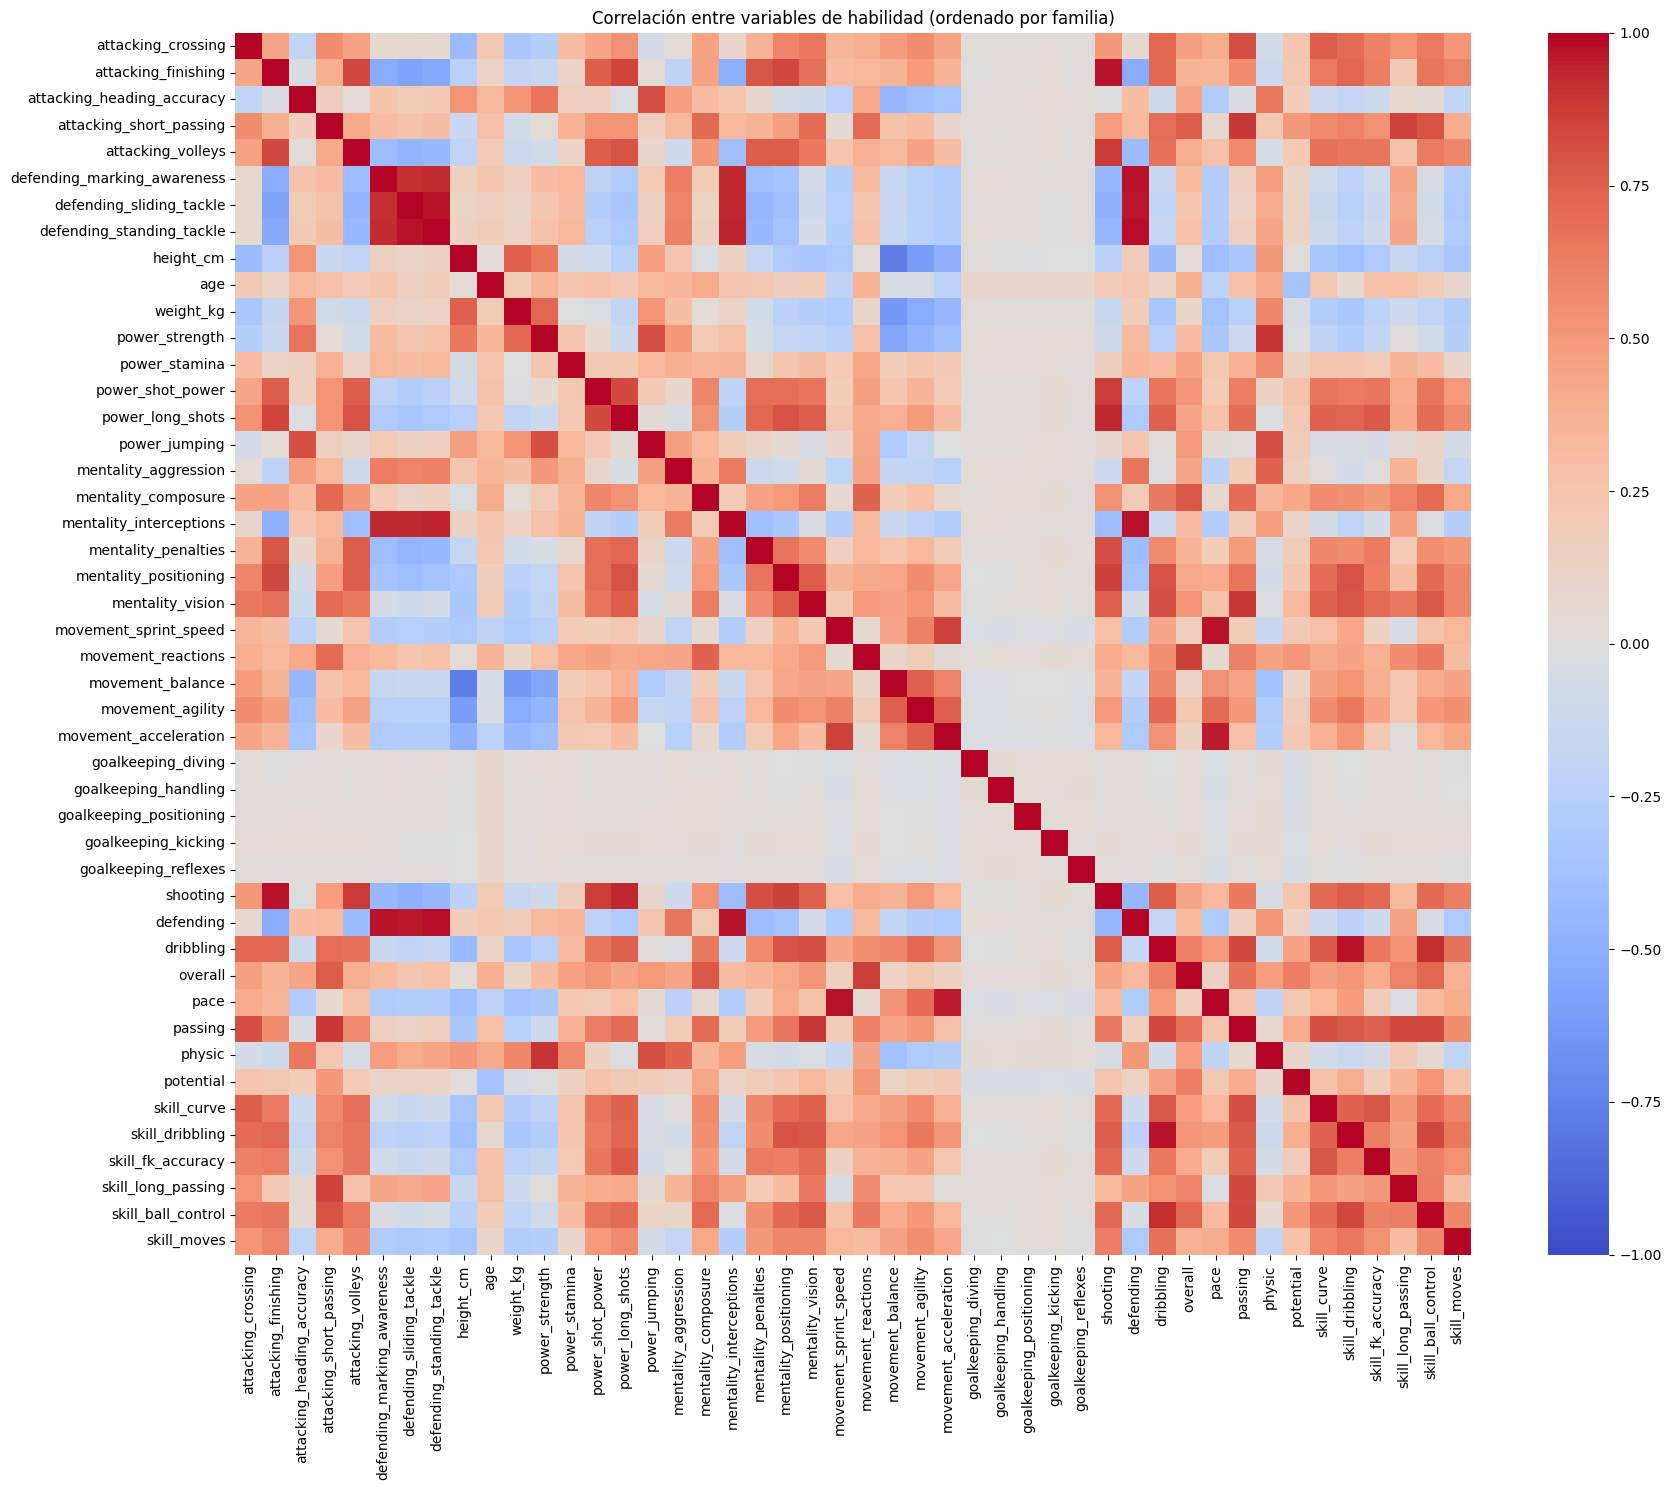

,var_1,var_2,corr
319,defending_standing_tackle,defending,0.979327
242,defending_marking_awareness,defending,0.973119
671,mentality_interceptions,defending,0.971197
975,dribbling,skill_dribbling,0.970952
255,defending_sliding_tackle,defending_standing_tackle,0.970877
75,attacking_finishing,shooting,0.970252
772,movement_sprint_speed,pace,0.968830
281,defending_sliding_tackle,defending,0.967233
854,movement_acceleration,pace,0.954623
304,defending_standing_tackle,mentality_interceptions,0.943345


In [187]:
orden_por_familia = familias_df.sort_values('familia')['columna'].tolist()
corr_habilidades = df_cluster_pop[orden_por_familia].corr()

plt.figure(figsize=(18,15))
sns.heatmap(corr_habilidades, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlación entre variables de habilidad (ordenado por familia)')
plt.tight_layout()
plt.show()

umbral_corr = 0.9
pares_redundantes = (
    corr_habilidades.where(np.triu(np.ones(corr_habilidades.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pares_redundantes.columns = ['var_1', 'var_2', 'corr']
pares_redundantes = pares_redundantes[pares_redundantes['corr'].abs() >= umbral_corr].sort_values('corr', ascending=False)
pares_redundantes

De la tabla de correlación surgen dos tipos de redundancia:

1. Las variables resumen (`pace`, `shooting`, `passing`, `dribbling`, `defending`, `physic`,
   más `overall`/`potential` por el mismo motivo aunque no siempre superen 0.9 con una sola
   variable) están construidas como combinación de sus propias granulares ya presentes en el
   vector, y quedarían sobrerrepresentadas si se dejan ambas.
2. La familia `Portería` no aporta información en `df_cluster_pop`, ya que este subconjunto
   son solo jugadores de campo (los ratings de arquero para ellos no reflejan habilidad real).

Se excluyen ambos grupos del vector de clustering. Dentro de cada familia restante (ej. las
tres variables de `Defensa`, correlacionadas entre 0.92-0.97) se decide **no** eliminar nada
adicional: la correlación alta ahí es esperable entre habilidades relacionadas y no doble
conteo literal de la misma variable.

In [188]:
familias_excluidas = ['Portería', 'Resumen global']

habilidades_num_campo = (
    familias_df
    .loc[~familias_df['familia'].isin(familias_excluidas)]
    .sort_values('familia')['columna']
    .tolist()
)

print(f"Variables antes de excluir: {len(familias_df)}")
print(f"Variables excluidas: { {f: (familias_df['familia']==f).sum() for f in familias_excluidas} }")
print(f"Variables finales para clustering: {len(habilidades_num_campo)}")

for fam in familias_df['familia'].unique():
    if fam not in familias_excluidas:
        vars_fam = familias_df.loc[familias_df['familia']==fam, 'columna'].tolist()
        print(f"\n{fam} ({len(vars_fam)}):")
        print(vars_fam)

habilidades_num_campo

Variables antes de excluir: 46
Variables excluidas: {'Portería': np.int64(5), 'Resumen global': np.int64(8)}
Variables finales para clustering: 33

Ataque (5):
['attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys']

Defensa (3):
['defending_marking_awareness', 'defending_sliding_tackle', 'defending_standing_tackle']

Mentalidad (6):
['mentality_aggression', 'mentality_composure', 'mentality_interceptions', 'mentality_penalties', 'mentality_positioning', 'mentality_vision']

Movimiento (5):
['movement_acceleration', 'movement_agility', 'movement_balance', 'movement_reactions', 'movement_sprint_speed']

Físico/Power (5):
['power_jumping', 'power_long_shots', 'power_shot_power', 'power_stamina', 'power_strength']

Técnica/Skill (6):
['skill_ball_control', 'skill_curve', 'skill_dribbling', 'skill_fk_accuracy', 'skill_long_passing', 'skill_moves']

Física (3):
['age', 'height_cm', 'weight_kg']


['attacking_crossing',
 'attacking_finishing',
 'attacking_heading_accuracy',
 'attacking_short_passing',
 'attacking_volleys',
 'defending_marking_awareness',
 'defending_sliding_tackle',
 'defending_standing_tackle',
 'age',
 'height_cm',
 'weight_kg',
 'power_shot_power',
 'power_strength',
 'power_stamina',
 'power_long_shots',
 'power_jumping',
 'mentality_aggression',
 'mentality_interceptions',
 'mentality_penalties',
 'mentality_composure',
 'mentality_vision',
 'mentality_positioning',
 'movement_reactions',
 'movement_agility',
 'movement_acceleration',
 'movement_sprint_speed',
 'movement_balance',
 'skill_ball_control',
 'skill_curve',
 'skill_dribbling',
 'skill_fk_accuracy',
 'skill_long_passing',
 'skill_moves']

## **3. Pregunta: ¿Se realizó alguna normalización o escalado de la base? ¿Por qué?**



Se aplica z-score porque las variables tienen escalas distintas entre sí; sin normalizar, las de mayor rango dominarían la distancia euclídea de K-means/jerárquico sin relación con su relevancia real.

In [189]:
# Comparamos rangos de las variables numéricas (antes de escalar)
rangos = pd.DataFrame({
    'min': df_cluster_pop[habilidades_num_campo].min(),
    'max': df_cluster_pop[habilidades_num_campo].max(),
    'rango': df_cluster_pop[habilidades_num_campo].max() - df_cluster_pop[habilidades_num_campo].min()
}).sort_values('rango', ascending=False)

rangos

,min,max,rango
mentality_positioning,11.0,96.0,85.0
attacking_finishing,12.0,96.0,84.0
skill_fk_accuracy,12.0,94.0,82.0
defending_standing_tackle,10.0,91.0,81.0
defending_marking_awareness,10.0,91.0,81.0
attacking_crossing,15.0,95.0,80.0
attacking_volleys,11.0,91.0,80.0
defending_sliding_tackle,10.0,90.0,80.0
mentality_interceptions,10.0,89.0,79.0
power_long_shots,15.0,92.0,77.0


In [190]:
# Aplicamos estandarización (z-score) sobre las 33 variables curadas en 2.8, sobre df_cluster_pop
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster_pop[habilidades_num_campo])
df_scaled = pd.DataFrame(X_scaled, columns=habilidades_num_campo, index=df_cluster_pop.index)

df_scaled.describe().T[['mean','std','min','max']]

,mean,std,min,max
attacking_crossing,-1.467969e-16,1.000032,-3.023220,3.096621
attacking_finishing,2.935937e-17,1.000032,-2.498271,2.814408
attacking_heading_accuracy,1.467969e-16,1.000032,-3.039174,3.180944
attacking_short_passing,1.174375e-16,1.000032,-4.612266,3.587302
attacking_volleys,1.174375e-16,1.000032,-2.532323,3.086285
defending_marking_awareness,1.467969e-17,1.000032,-2.395459,2.273242
defending_sliding_tackle,-1.467969e-17,1.000032,-2.271899,2.165896
defending_standing_tackle,-7.339844e-17,1.000032,-2.409684,2.078996
age,-8.807812e-17,1.000032,-2.054759,3.619249
height_cm,-6.991201e-16,1.000032,-3.804857,3.835381


4- Aplicación de clustering para encontrar grupos de jugadores con habilidades equivalentes, por ejemplo, jugadores que podrían intercambiarse en el caso de una lesión o cuando un jugador está cansado. Para esto utilice como mínimo dos técnicas de clustering: por ejemplo k-medias,MinShift, DBSCAN, mezcla de Gaussianas y/o Single linkage y otras jerárquicas. Justifiquen por qué eligen los diferentes hiper-parámetros que se puedan elegir según el método: número de clusters, medida de distancia, criterio de aglomeración… Utilicen al menos una métrica cuantitativa de evaluación de clustering (por ejemplo, coeficiente de silhouette, índice de rand ajustado, u otra que consideren pertinente) para comparar los resultados obtenidos con las distintas técnicas y/o configuraciones de hiperparámetros probadas, y justifiquen a partir de esas métricas cuál configuración/método les resultó más adecuado.

5- Análisis cualitativo de los clusters encontrados. ¿Qué hay en cada cluster? ¿Son efectivamente equivalentes los jugadores de un cluster, es decir, podrían cumplir el mismo rol en un equipo? Si se trata de clusters heterogéneos, ¿por qué razón pueden haber sido agrupadas las jugadoras del cluster? ¿Qué motiva las diferencias en tamaño?

6- Uso de alguna transformación (proyección, Embedding) para visualizar los resultados y/o usarla como preprocesado para aplicar alguna técnica de clustering.

7- Comparación de interpretaciones humano vs. LLMs sobre el análisis de clusters, para reflexionar críticamente sobre el rol del conocimiento experto/de dominio frente a la interpretación automática de resultados de clustering, y sobre las capacidades y limitaciones actuales de los modelos de lenguaje para el análisis de datos.

a) Tomar los resultados del punto 5 (caracterización de clusters ya realizada por el grupo) y presentarle a Claude, ChatGPT y Gemini exactamente la misma información: por ejemplo, tabla de centroides/estadísticos descriptivos por cluster, tamaño de cada cluster, y las variables utilizadas para clusterizar (sin incluir la interpretación propia del grupo, para no sesgar al modelo).

b) Pedirle a cada uno de los tres modelos, con el mismo prompt, que interprete los clusters: qué representa cada uno, si los jugadores dentro de un cluster son "equivalentes", y qué podría explicar la heterogeneidad o el tamaño de los grupos.

c) Documentar textualmente (o via capturas) las tres respuestas obtenidas.

d) Realizar un análisis comparativo entre las tres respuestas y la interpretación propia del grupo (la del punto 5), atendiendo especialmente a:

- Coincidencias y diferencias entre los tres modelos.

- Casos en que algún modelo haya "alucinado" datos, sacado conclusiones no sustentadas por los números, o generalizado de forma poco rigurosa.

- Casos en que el grupo, gracias a conocimiento de dominio (reglas del fútbol, entendimiento de posiciones, lógica de mercado de pases, conocimiento de jugadores reales, contexto de la temporada/base de datos, etc.), pudo identificar matices, errores o explicaciones que ningún modelo mencionó.

- Información contextual que un experto humano valora naturalmente pero que los modelos no tienen forma de inferir sólo de números (ej.: un jugador lesionado en el momento del snapshot de datos, un jugador joven con potencial subestimado por las métricas actuales, diferencias entre ligas de distinto nivel competitivo que igualan estadísticas de forma engañosa, etc.).

- Diferencias en el "tono" de certeza: ¿los modelos matizan sus afirmaciones o presentan interpretaciones especulativas como si fueran hechos?

e) Conclusión breve reflexionando sobre: ¿en qué tareas de este análisis un LLM aporta valor real (por ejemplo, generación rápida de hipótesis, redacción, resumen)? ¿En qué tareas resulta insuficiente o directamente engañoso sin supervisión experta? ¿Qué rol debería tener, en la práctica profesional de un/a científico/a de datos, el uso de estas herramientas para interpretar resultados de un análisis no supervisado?